# ¿Cuánto vale esta casa? — Regresión de precios con una MLP

**Grupo 2**

- Candelaria Perles
- Julián Ritondale
- María Pia Andreuccetti
- Juan Decoud

---

La misión cambia la pregunta de clase. Antes preguntábamos *¿está por encima de la mediana?*
(sigmoide + `binary_crossentropy`, un sí o un no). Ahora preguntamos **¿cuántos dólares vale?**,
que es un número real: cambia la última capa (`Dense(1)` lineal), cambia la loss (MSE) y cambian
las métricas (MAE / RMSE / MAPE en lugar de accuracy).

Y cambia la entrada: hay estado, distrito, estilo de casa y mes de venta. Nada de eso entra en un
`Dense` tal como viene, así que el trabajo pesado está en el **Milestone 1**, antes de escribir una
sola capa.

### Cómo está organizado el notebook

| Sección | Qué hay |
|---|---|
| Milestone 1 | La tabla de decisiones, columna por columna, con las trampas marcadas |
| Milestone 2 | Baseline con columnas numéricas solamente |
| Milestone 3 | Entran las categóricas (one-hot vs. embedding) + ablación por bloque |
| Milestone 4 | Overfitting a propósito y su corrección (L2 + dropout + early stopping) |
| Milestone 5 | Tasar una casa escrita como la escribe una persona |
| Preguntas 1–5 | Respondidas en markdown, cada una pegada a su código / gráfico |
| Extra | P10 / P50 / P90 con pinball loss |

> **Reproducibilidad:** el notebook corre de arriba a abajo con *Restart & Run All* en una máquina
> que solo tenga `house-prices-extended.csv` al lado (si no está, lo descarga). Todas las semillas
> están fijadas; puede haber diferencias de decimales entre corridas por el no-determinismo de las
> operaciones en CPU/GPU, pero las conclusiones no cambian.
>
> **Tiempo de corrida:** entrena unos 35 modelos en total (los milestones, más los experimentos
> "mal a propósito" de las preguntas, varios de ellos repetidos con 3 semillas para separar el
> efecto real del ruido de inicialización). En CPU son **~40 minutos**; en la GPU de Colab, bastante
> menos.

In [1]:
# ============================================================================
#  Setup: imports, semillas y carga del dataset
# ============================================================================
%matplotlib inline

import os
import warnings

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # menos ruido de TensorFlow
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, ops
from sklearn.model_selection import train_test_split

tf.get_logger().setLevel("ERROR")                    # idem, para los warnings de deprecacion

SEED = 42
keras.utils.set_random_seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

CSV_NAME = "house-prices-extended.csv"
CSV_URL = ("https://austral-ing-ai.github.io/talksmith-ing/missions/mlp/"
           "house-prices-extended.csv")

if not os.path.exists(CSV_NAME):        # red solo si el csv no está al lado
    import urllib.request
    print("csv no encontrado localmente, descargando...")
    urllib.request.urlretrieve(CSV_URL, CSV_NAME)

df = pd.read_csv(CSV_NAME)

print(f"TensorFlow {tf.__version__} | Keras {keras.__version__}")
print(f"dataset: {df.shape[0]} casas, {df.shape[1]} columnas")
df.head()

TensorFlow 2.21.0 | Keras 3.15.1
dataset: 1460 casas, 20 columnas


,ListingId,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,SalePrice
0,677742,8450,7,5,856,2,1,3,8,0,548,1970,64.0,7,IL,Larkspur,Townhouse,N,Normal,172700
1,551423,9600,6,8,1262,2,0,3,6,1,460,1935,73.0,11,CA,Greenfield,2Story,Y,Normal,369700
2,237268,11250,7,5,920,2,1,3,6,1,608,1949,80.0,9,AZ,Fernwood,1Story,Y,Normal,165700
3,579284,9550,7,5,756,1,0,3,7,1,642,1924,72.0,7,FL,Stonegate,2Story,Y,Normal,164300
4,598125,14260,8,5,1145,2,1,4,9,1,836,1951,87.0,2,NC,Xavier Park,Loft,Y,Normal,283700


In [2]:
# Perfil rápido de cada columna: es la materia prima de la tabla de decisiones.
perfil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(1),
    "ejemplo": [df[c].dropna().iloc[0] for c in df.columns],
})
perfil

,dtype,n_unicos,n_faltantes,pct_faltantes,ejemplo
ListingId,int64,1460,0,0.0,677742
LotArea,int64,1073,0,0.0,8450
OverallQual,int64,10,0,0.0,7
OverallCond,int64,9,0,0.0,5
TotalBsmtSF,int64,721,0,0.0,856
FullBath,int64,4,0,0.0,2
HalfBath,int64,3,0,0.0,1
BedroomAbvGr,int64,8,0,0.0,3
TotRmsAbvGrd,int64,12,0,0.0,8
Fireplaces,int64,4,0,0.0,0


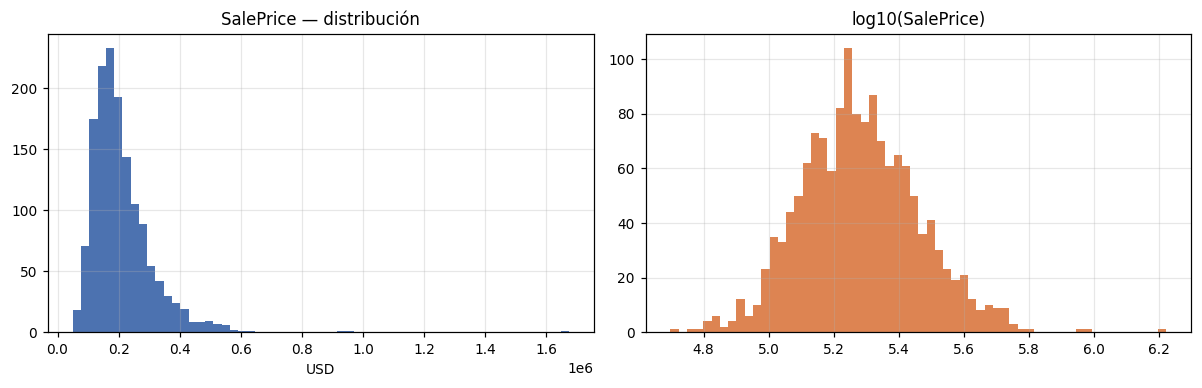

count       1460.0
mean      209091.0
std       101470.0
min        49800.0
25%       142650.0
50%       186700.0
75%       250600.0
max      1674700.0

asimetria (skew) = 3.45  -> cola derecha larga
top 5 precios: [1674700, 944000, 931700, 636300, 595300]


In [3]:
# Distribución del precio: importa para elegir la métrica (Pregunta 1).
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(df.SalePrice, bins=60, color="#4C72B0")
ax[0].set_title("SalePrice — distribución")
ax[0].set_xlabel("USD")
ax[1].hist(np.log10(df.SalePrice), bins=60, color="#DD8452")
ax[1].set_title("log10(SalePrice)")
plt.tight_layout(); plt.show()

print(df.SalePrice.describe().round(0).to_string())
print(f"\nasimetria (skew) = {df.SalePrice.skew():.2f}  -> cola derecha larga")
print("top 5 precios:", sorted(df.SalePrice.nlargest(5).tolist(), reverse=True))

## Milestone 1 — La tabla de decisiones

Cada columna pasa por el checklist de la clase antes de tocar la red:

1. **¿Qué es?** (identificador / cantidad / orden / etiqueta)
2. **¿Qué significa la resta entre dos valores?** — si `a - b` no significa nada, la columna no
   puede entrar como número.
3. **¿Cuántos valores distintos tiene?** — decide one-hot vs. embedding.
4. **¿Puede faltar?** — decide si hace falta imputar y si el faltante es informativo.
5. **¿La voy a tener al momento de predecir?** — si no, es fuga de información, no una feature.

### La tabla

| # | Columna | Qué es | ¿Qué significa la resta? | N° valores | ¿Falta? | ¿Está al predecir? | Codificación elegida | Motivo |
|---|---|---|---|---|---|---|---|---|
| 1 | `ListingId` | Identificador del aviso | Nada: `677742 - 551423` no es "más caro" ni "más viejo" | 1460 (uno por fila) | No | Sí, pero es irrelevante | **SE DESCARTA** 🚩 | Es una etiqueta de base de datos disfrazada de número; solo sirve para memorizar (Pregunta 3) |
| 2 | `LotArea` | Cantidad continua (pies²) | Diferencia de superficie de terreno: interpretable | 1073 | No | Sí | Numérica + estandarizada | Escala real, resta con sentido |
| 3 | `OverallQual` | Orden (ordinal 1–10) | Un escalón de calidad; se asumen escalones parejos | 10 | No | Sí | Numérica + estandarizada | Está ordenada y es monótona con el precio (corr ≈ 0.66): tratarla como número usa esa monotonía con 1 peso en vez de 10 |
| 4 | `OverallCond` | Orden (ordinal 1–9) | Un escalón de estado de conservación | 9 | No | Sí | Numérica + estandarizada | Ordinal genuina, igual que arriba |
| 5 | `TotalBsmtSF` | Cantidad continua (pies²) | Diferencia de superficie de sótano | 721 | No | Sí | Numérica + estandarizada | Escala real |
| 6 | `FullBath` | Conteo | Un baño completo más | 4 | No | Sí | Numérica + estandarizada | Conteo chico y monótono |
| 7 | `HalfBath` | Conteo | Medio baño más | 3 | No | Sí | Numérica + estandarizada | Conteo chico y monótono |
| 8 | `BedroomAbvGr` | Conteo | Un dormitorio más | 8 | No | Sí | Numérica + estandarizada | Conteo |
| 9 | `TotRmsAbvGrd` | Conteo | Un ambiente más | 12 | No | Sí | Numérica + estandarizada | Conteo |
| 10 | `Fireplaces` | Conteo | Un hogar más | 4 | No | Sí | Numérica + estandarizada | Conteo |
| 11 | `GarageArea` | Cantidad continua (pies²) | Diferencia de superficie de garaje | 441 | No | Sí | Numérica + estandarizada | Escala real |
| 12 | `YearBuilt` | Cantidad en escala de intervalo (año) | Años de diferencia de antigüedad: sí significa algo | 100 | No | Sí | Numérica + estandarizada | La resta es interpretable; el cero es arbitrario pero la estandarización lo reubica |
| 13 | `LotFrontage` | Cantidad continua (pies de frente) | Diferencia de frente del lote | 115 | **Sí, 103 filas (7.1%)** 🚩 | Sí | Imputación por **mediana de train** + **columna binaria `LotFrontage_faltante`**, ambas estandarizadas | Rellenar con 0 le miente a la red ("frente cero"); y el faltante en sí trae señal (Pregunta 4) |
| 14 | `MonthSold` | **Etiqueta cíclica** (1–12) 🚩 | `12 - 1 = 11` dice que diciembre y enero están lejísimos, y están pegados | 12 | No | Sí (se elige la fecha de tasación) | **One-hot de 12** (alternativa: `sin`/`cos` del ángulo) | Viene como `int64` y entraría solo al `Dense`, pero no es una cantidad: es un mes. Sin orden lineal ni ciclo roto |
| 15 | `State` | Etiqueta nominal | Nada: `'CA' - 'TX'` no existe | 12 | No | Sí | **One-hot de 12** | Cardinalidad baja: 12 columnas es barato y cada estado queda con su propio peso, interpretable |
| 16 | `District` | Etiqueta nominal de alta cardinalidad | Nada | **72** 🚩 | No | Sí | **Embedding de dimensión 8** (`StringLookup` → `Embedding`) | 72 columnas one-hot son casi todas ceros y hay ~20 filas por categoría; el embedding comparte estructura entre distritos parecidos con 8 números en vez de 72 (Pregunta 2) |
| 17 | `HouseStyle` | Etiqueta nominal | Nada | 6 | No | Sí | One-hot de 6 | Nominal de cardinalidad baja |
| 18 | `CentralAir` | Etiqueta binaria (`Y`/`N`) | Nada como string; como 0/1 sí | 2 | No | Sí | One-hot de 2 (equivale a una binaria 0/1) | Dos valores: una columna alcanza |
| 19 | `SaleCondition` | Etiqueta nominal | Nada | 5 | No | **Discutible** 🚩 | One-hot de 5, **marcada como sospechosa** | Describe *cómo se cerró la venta* (`Partial`, `Abnorml`, `Family`): al tasar una casa que todavía no se vendió no se conoce. Ver la nota de abajo |
| 20 | `SalePrice` | **Target** — cantidad continua en USD | Diferencia de precio en dólares | 1125 | No | — (es lo que se predice) | `Dense(1)` lineal + loss MSE | Es un real positivo sin techo, no una probabilidad ni una clase |

### Las trampas 🚩

El enunciado avisa que hay **al menos tres**. Encontramos cinco:

1. **`ListingId` es un identificador, no una feature.** Es `int64`, entra al `Dense` sin protestar
   y la red lo usa como índice de memorización. No da error: da curvas de entrenamiento lindas y
   validación estancada. → **Pregunta 3.**
2. **`District` con 72 valores no es un one-hot y, mucho menos, un entero 0–71.** Como entero, la
   red asume que el distrito 5 está "entre" el 4 y el 6 y que el efecto es monótono en el código,
   que es un orden alfabético arbitrario. → **Pregunta 2.**
3. **`MonthSold` viene como número y no es un número.** Es la trampa más silenciosa: `dtype=int64`
   lo mete en el bloque numérico sin que nadie lo note, y ahí la red aprende una pendiente
   "el precio sube con el mes", con enero y diciembre en las puntas opuestas de una recta cuando
   en realidad son meses consecutivos.
4. **`LotFrontage` falta en el 7% de las filas** y la tentación es `fillna(0)`. Cero pies de frente
   es una casa sin frente: un valor *plausible y falso*, que además arrastra la media y el desvío
   del escalador. → **Pregunta 4.**
5. **`SaleCondition` puede no estar disponible al momento de predecir.** El checklist tiene esa
   pregunta justamente para esto. La dejamos dentro del modelo porque el enunciado pide sumar las
   columnas no numéricas, pero medimos abajo (Milestone 3) cuánto aporta: si el tasador no la
   conoce, hay que reentrenar sin ella. Es una decisión de producto, no de código.

### Nota sobre `State` y `District`

En este dataset los 72 distritos están **anidados en los 12 estados** (6 distritos por estado, sin
repetirse). Es decir, `District` ya implica `State`. Igual dejamos las dos: el one-hot de `State`
le da a la red el efecto "estado" con 12 pesos estimados con ~120 casas cada uno, mientras el
embedding de `District` afina dentro del estado con ~20 casas por distrito. Lo verificamos:

distritos por estado: [6] | distritos totales: 72
un distrito en mas de un estado? False


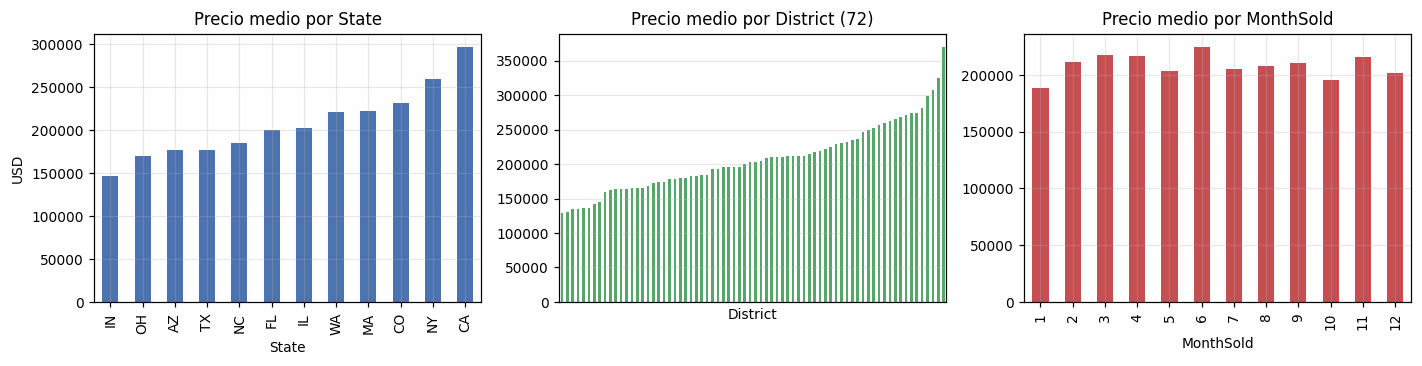


rango del precio medio entre estados:      146,250 ..    297,105 USD
rango del precio medio entre distritos:    129,455 ..    370,322 USD
rango del precio medio entre meses:        188,439 ..    224,758 USD   <- mucho mas plano: MonthSold aporta poco


In [4]:
# Verificación del anidado District -> State y de la señal que trae cada categórica.
print("distritos por estado:", df.groupby("State").District.nunique().unique(),
      "| distritos totales:", df.District.nunique())
print("un distrito en mas de un estado?",
      bool((df.groupby("District").State.nunique() > 1).any()))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
df.groupby("State").SalePrice.mean().sort_values().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Precio medio por State"); ax[0].set_ylabel("USD")
df.groupby("District").SalePrice.mean().sort_values().plot.bar(ax=ax[1], color="#55A868")
ax[1].set_title("Precio medio por District (72)"); ax[1].set_xticks([])
df.groupby("MonthSold").SalePrice.mean().plot.bar(ax=ax[2], color="#C44E52")
ax[2].set_title("Precio medio por MonthSold")
plt.tight_layout(); plt.show()

st = df.groupby("State").SalePrice.mean()
di = df.groupby("District").SalePrice.mean()
mo = df.groupby("MonthSold").SalePrice.mean()
print(f"\nrango del precio medio entre estados:   {st.min():>10,.0f} .. {st.max():>10,.0f} USD")
print(f"rango del precio medio entre distritos: {di.min():>10,.0f} .. {di.max():>10,.0f} USD")
print(f"rango del precio medio entre meses:     {mo.min():>10,.0f} .. {mo.max():>10,.0f} USD"
      "   <- mucho mas plano: MonthSold aporta poco")

---
## Infraestructura: split, preprocesamiento *dentro* del modelo y helpers

Antes de los milestones, tres decisiones que se aplican a todo lo que sigue.

**1. El split va primero.** Partimos el dataset en train / validación / test **antes** de calcular
cualquier estadístico (medias, desvíos, medianas, vocabularios de categorías). Todo lo que el
preprocesamiento necesita saber se aprende **solo de train**. Esto es el tema de la Pregunta 5.

**2. El preprocesamiento es parte del modelo.** No hay un `scaler` suelto en una variable del
notebook. Usamos capas de Keras (`Normalization`, `StringLookup`, `IntegerLookup`,
`CategoryEncoding`, `Embedding`) más dos capas propias, y todas viven dentro del grafo. El modelo
recibe un diccionario con los valores **crudos** de una casa (`State='CA'`, `LotFrontage=nan`, …) y
devuelve dólares. Eso es lo que permite `model.save()` / `load_model()` y usarlo en otra máquina.

**3. La última capa la decide el problema.** `Dense(n)` con activación **lineal** (identidad), no
sigmoide: el target es un real positivo sin techo, no una probabilidad. La loss es **MSE**, no
`binary_crossentropy`. La capa `ADolares` al final es una transformación afín **fija** (no
entrenable) que devuelve la salida a dólares; existe para que la red trabaje en unidades
estandarizadas y arranque prediciendo el precio medio de train, no cero.

In [5]:
# ============================================================================
#  Split train / val / test  —  64% / 16% / 20%
# ============================================================================
df_tr_full, df_te = train_test_split(df, test_size=0.20, random_state=SEED)
df_tr, df_va = train_test_split(df_tr_full, test_size=0.20, random_state=SEED)

y_tr = df_tr.SalePrice.to_numpy("float32")
y_va = df_va.SalePrice.to_numpy("float32")
y_te = df_te.SalePrice.to_numpy("float32")

print(f"train {len(df_tr):>5}   val {len(df_va):>5}   test {len(df_te):>5}")
print(f"precio medio  train {y_tr.mean():>10,.0f}   val {y_va.mean():>10,.0f}   "
      f"test {y_te.mean():>10,.0f}")

# --- Estadísticos aprendidos SOLO de train -----------------------------------
MEDIANA_LOTFRONTAGE = float(df_tr.LotFrontage.median())
Y_MEDIA, Y_DESVIO = float(y_tr.mean()), float(y_tr.std())

VOCAB = {c: sorted(df_tr[c].dropna().unique().tolist())
         for c in ["State", "District", "HouseStyle", "CentralAir", "SaleCondition"]}

print(f"\nmediana de LotFrontage en train: {MEDIANA_LOTFRONTAGE:.1f} pies")
print(f"target en train: media {Y_MEDIA:,.0f}  desvio {Y_DESVIO:,.0f}")
print({k: len(v) for k, v in VOCAB.items()})

train   934   val   234   test   292
precio medio  train    210,711   val    215,453   test    198,810

mediana de LotFrontage en train: 70.0 pies
target en train: media 210,711  desvio 104,321
{'State': 12, 'District': 72, 'HouseStyle': 6, 'CentralAir': 2, 'SaleCondition': 5}


In [6]:
# ============================================================================
#  Grupos de columnas segun la tabla de decisiones
# ============================================================================
NUM = ["LotArea", "OverallQual", "OverallCond", "TotalBsmtSF", "FullBath", "HalfBath",
       "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageArea", "YearBuilt"]
NUM_CON_NAN = ["LotFrontage"]                       # imputada + indicador, dentro del modelo
CAT_ONEHOT = ["State", "HouseStyle", "CentralAir", "SaleCondition"]   # baja cardinalidad
CAT_EMBED = {"District": 8}                          # alta cardinalidad -> embedding dim 8
CAT_ONEHOT_INT = ["MonthSold"]                       # ciclica: one-hot, NO numerica
DESCARTADAS = ["ListingId"]                          # identificador

print("numericas          :", len(NUM), NUM)
print("numerica con NaN   :", NUM_CON_NAN)
print("one-hot (string)   :", CAT_ONEHOT)
print("one-hot (entero)   :", CAT_ONEHOT_INT)
print("embedding          :", CAT_EMBED)
print("descartadas        :", DESCARTADAS)

numericas          : 11 ['LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea', 'YearBuilt']
numerica con NaN   : ['LotFrontage']
one-hot (string)   : ['State', 'HouseStyle', 'CentralAir', 'SaleCondition']
one-hot (entero)   : ['MonthSold']
embedding          : {'District': 8}
descartadas        : ['ListingId']


In [7]:
# ============================================================================
#  Dos capas propias: imputacion con indicador, y vuelta a dolares
# ============================================================================
@keras.saving.register_keras_serializable(package="tasador")
class ImputarNaN(keras.layers.Layer):
    """Reemplaza NaN por un valor fijo y (opcionalmente) concatena la mascara de faltantes.

    El valor de relleno se aprende de train y queda guardado en el modelo: viaja con los
    pesos, no en una variable del notebook.
    """

    def __init__(self, valor, con_indicador=True, **kw):
        super().__init__(**kw)
        self.valor = float(valor)
        self.con_indicador = bool(con_indicador)

    def call(self, x):
        falta = ops.cast(ops.isnan(x), x.dtype)
        lleno = ops.where(ops.isnan(x), ops.cast(self.valor, x.dtype), x)
        return ops.concatenate([lleno, falta], axis=-1) if self.con_indicador else lleno

    def compute_output_shape(self, shape):
        return (shape[0], shape[-1] * 2) if self.con_indicador else shape

    def get_config(self):
        return {**super().get_config(), "valor": self.valor,
                "con_indicador": self.con_indicador}


@keras.saving.register_keras_serializable(package="tasador")
class ADolares(keras.layers.Layer):
    """Transformacion afin FIJA (no entrenable): unidades estandarizadas -> dolares.

    Es el 'escalador del target' y viaja dentro del modelo. Gracias a esta capa la red
    arranca prediciendo el precio medio de train en vez de 0.
    """

    def __init__(self, media, desvio, **kw):
        super().__init__(**kw)
        self.media = float(media)
        self.desvio = float(desvio)

    def call(self, z):
        return z * self.desvio + self.media

    def get_config(self):
        return {**super().get_config(), "media": self.media, "desvio": self.desvio}


print("capas propias registradas:", ImputarNaN.__name__, "y", ADolares.__name__)

capas propias registradas: ImputarNaN y ADolares


In [8]:
# ============================================================================
#  Armado del tensor de entrada y constructor de modelos
# ============================================================================
def a_entradas(frame, cfg):
    """DataFrame -> dict de arrays con el dtype que espera cada Input del modelo."""
    X = {}
    for c in cfg.get("num", []) + cfg.get("num_nan", []) + cfg.get("ordinal_num", []):
        X[c] = frame[c].to_numpy("float32").reshape(-1, 1)
    for c in cfg.get("onehot", []) + list(cfg.get("embed", {})) + cfg.get("ordinal_cat", []):
        # las columnas de texto van como tensores tf.string: numpy no tiene un dtype
        # de string que Keras acepte (ni 'object' ni '<U64')
        X[c] = tf.reshape(tf.constant(frame[c].astype(str).tolist(), dtype=tf.string), (-1, 1))
    for c in cfg.get("onehot_int", []):
        X[c] = frame[c].to_numpy("int64").reshape(-1, 1)
    return X


def matriz_numerica(cfg, frame=None):
    """Replica en numpy lo que el bloque numerico del modelo produce, para llamar a .adapt().

    Por defecto se calcula sobre TRAIN (lo correcto). En la Pregunta 5 la llamamos sobre el
    dataset completo para mostrar la fuga.
    """
    frame = df_tr if frame is None else frame
    relleno = cfg.get("relleno", MEDIANA_LOTFRONTAGE)
    partes = [frame[c].to_numpy("float32").reshape(-1, 1) for c in cfg.get("num", [])]
    for c in cfg.get("num_nan", []):
        col = frame[c].to_numpy("float32").reshape(-1, 1)
        falta = np.isnan(col).astype("float32")
        lleno = np.where(np.isnan(col), np.float32(relleno), col)
        partes += ([lleno, falta] if cfg.get("indicador", True) else [lleno])
    for c in cfg.get("ordinal_num", []):
        partes.append(frame[c].to_numpy("float32").reshape(-1, 1))
    for c in cfg.get("ordinal_cat", []):     # codigo entero 0..K-1 (la version "mal a proposito")
        # StringLookup reserva el indice 0 para OOV, asi que los codigos van de 1 a K
        codigo = frame[c].astype(str).map({v: i + 1 for i, v in enumerate(VOCAB[c])}).fillna(0)
        partes.append(codigo.to_numpy("float32").reshape(-1, 1))
    return np.concatenate(partes, axis=1) if partes else None


def construir(cfg, capas=(128, 64), dropout=0.0, l2=0.0, n_salidas=1,
              nombre="modelo", norm_frame=None):
    """Modelo funcional con TODO el preprocesamiento adentro.

    cfg: dict con las claves num / num_nan / onehot / onehot_int / embed / ordinal_num /
         ordinal_cat / indicador.
    norm_frame: DataFrame sobre el que se adapta la Normalization. Por defecto TRAIN
         (lo correcto). En la Pregunta 5 le pasamos el dataset completo para mostrar la fuga.
    """
    reg = keras.regularizers.L2(l2) if l2 else None
    entradas, ramas = {}, []

    # ---- bloque numerico (una sola Normalization sobre el vector concatenado) ----
    num_partes = []
    for c in cfg.get("num", []):
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="float32")
        num_partes.append(entradas[c])
    for c in cfg.get("num_nan", []):
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="float32")
        num_partes.append(ImputarNaN(cfg.get("relleno", MEDIANA_LOTFRONTAGE),
                                     con_indicador=cfg.get("indicador", True),
                                     name=f"imputar_{c}")(entradas[c]))
    for c in cfg.get("ordinal_num", []):        # numericas que NO deberian estar (ListingId)
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="float32")
        num_partes.append(entradas[c])
    for c in cfg.get("ordinal_cat", []):        # categorica leida como entero 0..K-1
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="string")
        idx = layers.StringLookup(vocabulary=VOCAB[c], name=f"codigo_{c}")(entradas[c])
        num_partes.append(layers.Lambda(lambda t: ops.cast(t, "float32"),
                                        output_shape=(1,), name=f"a_float_{c}")(idx))

    if num_partes:
        x_num = (num_partes[0] if len(num_partes) == 1
                 else layers.Concatenate(name="numericas")(num_partes))
        normalizador = layers.Normalization(name="estandarizar")
        base = matriz_numerica(cfg) if norm_frame is None else norm_frame
        normalizador.adapt(base)
        ramas.append(normalizador(x_num))

    # ---- categoricas de baja cardinalidad -> one-hot ----
    for c in cfg.get("onehot", []):
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="string")
        idx = layers.StringLookup(vocabulary=VOCAB[c], name=f"lookup_{c}")(entradas[c])
        ramas.append(layers.CategoryEncoding(num_tokens=len(VOCAB[c]) + 1,
                                             output_mode="one_hot",
                                             name=f"onehot_{c}")(idx))
    for c in cfg.get("onehot_int", []):
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="int64")
        vocab = sorted(df_tr[c].unique().tolist())
        idx = layers.IntegerLookup(vocabulary=vocab, name=f"lookup_{c}")(entradas[c])
        ramas.append(layers.CategoryEncoding(num_tokens=len(vocab) + 1,
                                             output_mode="one_hot",
                                             name=f"onehot_{c}")(idx))

    # ---- categoricas de alta cardinalidad -> embedding ----
    for c, dim in cfg.get("embed", {}).items():
        entradas[c] = keras.Input(shape=(1,), name=c, dtype="string")
        idx = layers.StringLookup(vocabulary=VOCAB[c], name=f"lookup_{c}")(entradas[c])
        emb = layers.Embedding(len(VOCAB[c]) + 1, dim, name=f"embedding_{c}")(idx)
        ramas.append(layers.Flatten(name=f"flat_{c}")(emb))

    x = ramas[0] if len(ramas) == 1 else layers.Concatenate(name="features")(ramas)

    # ---- MLP ----
    for i, u in enumerate(capas):
        x = layers.Dense(u, activation="relu", kernel_regularizer=reg, name=f"dense_{i}")(x)
        if dropout:
            x = layers.Dropout(dropout, name=f"dropout_{i}")(x)

    # ---- la ultima capa: LINEAL (identidad), no sigmoide ----
    z = layers.Dense(n_salidas, activation="linear", name="salida_estandarizada")(x)
    salida = ADolares(Y_MEDIA, Y_DESVIO, name="a_dolares")(z)

    return keras.Model(entradas, salida, name=nombre)

In [9]:
# ============================================================================
#  Helpers de entrenamiento y evaluacion
# ============================================================================
RESULTADOS = []          # se va llenando a lo largo del notebook


def entrenar(modelo, cfg, epocas=300, lr=1e-3, batch=64, paciencia=40, loss="mse",
             verbose=0, usar_val=True):
    # la metrica MAE solo tiene sentido con una salida (el modelo de cuantiles tiene tres)
    metricas_keras = ([keras.metrics.MeanAbsoluteError(name="mae")]
                      if modelo.output_shape[-1] == 1 else [])
    modelo.compile(optimizer=keras.optimizers.Adam(lr), loss=loss, metrics=metricas_keras)
    cbs = []
    if paciencia:
        cbs.append(keras.callbacks.EarlyStopping(monitor="val_loss", patience=paciencia,
                                                 restore_best_weights=True))
    hist = modelo.fit(a_entradas(df_tr, cfg), y_tr,
                      validation_data=(a_entradas(df_va, cfg), y_va) if usar_val else None,
                      epochs=epocas, batch_size=batch, verbose=verbose, callbacks=cbs)
    return hist


def metricas(y_true, y_pred, nombre=None, registrar=True):
    y_pred = np.asarray(y_pred).ravel().astype("float64")
    y_true = np.asarray(y_true).ravel().astype("float64")
    err = y_pred - y_true
    d = {"modelo": nombre,
         "MAE": float(np.abs(err).mean()),
         "RMSE": float(np.sqrt((err ** 2).mean())),
         "MAPE_%": float((np.abs(err) / y_true).mean() * 100)}
    if registrar and nombre:
        RESULTADOS.append(d)
    return d


def evaluar(modelo, cfg, nombre, registrar=True, frame=None, y=None):
    frame = df_te if frame is None else frame
    y = y_te if y is None else y
    pred = modelo.predict(a_entradas(frame, cfg), verbose=0)
    d = metricas(y, pred, nombre, registrar)
    print(f"{nombre:<44}  MAE {d['MAE']:>9,.0f}   RMSE {d['RMSE']:>9,.0f}   "
          f"MAPE {d['MAPE_%']:>6.2f}%")
    return pred.ravel(), d


def curvas(hists, titulos, sup=None, ylim=None):
    """Curvas de loss (MSE) train vs val, en escala log."""
    n = len(hists)
    fig, axes = plt.subplots(1, n, figsize=(5.6 * n, 3.6), squeeze=False)
    for ax, h, t in zip(axes[0], hists, titulos):
        ax.plot(h.history["loss"], label="train", lw=1.4)
        if "val_loss" in h.history:
            ax.plot(h.history["val_loss"], label="validacion", lw=1.4)
        ax.set_yscale("log"); ax.set_xlabel("epoca"); ax.set_ylabel("loss (MSE, USD²)")
        ax.set_title(t, fontsize=9); ax.legend()
        if ylim:
            ax.set_ylim(*ylim)
    if sup:
        fig.suptitle(sup, y=1.04, fontsize=11)
    plt.tight_layout(); plt.show()


def tabla_resultados(filtro=None):
    t = pd.DataFrame(RESULTADOS)
    if filtro:
        t = t[t.modelo.str.contains(filtro)]
    return (t.drop_duplicates("modelo", keep="last")
             .style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "MAPE_%": "{:.2f}"})
             .hide(axis="index"))

print("helpers listos")

helpers listos


## Milestone 2 — Baseline numérico

Solo las columnas **numéricas de verdad**: las 11 de la clase más `YearBuilt`, más `LotFrontage`
imputada con la mediana de train y su indicador de faltante. **No** entran `ListingId` (es un id)
ni `MonthSold` (es un mes disfrazado de entero), por lo que dice la tabla de decisiones.

### La última capa

| | Clase (¿arriba de la mediana?) | Esta misión (¿cuántos dólares?) |
|---|---|---|
| Última capa | `Dense(1, activation='sigmoid')` | `Dense(1, activation='linear')` |
| Loss | `binary_crossentropy` | `mse` |
| Métrica | `accuracy` | `MAE`, `RMSE`, `MAPE` |
| Salida | número en (0, 1) = probabilidad | número real en (−∞, ∞) = dólares |

**Por qué la `accuracy` acá no significa nada.** `accuracy` compara la clase predicha con la clase
real y cuenta aciertos exactos. Sobre un real continuo, "acertar" es tener el mismo `float`: si el
modelo predice 172.699,98 y la casa valía 172.700, la accuracy lo cuenta como error igual que si
hubiera predicho 40.000. Con 1125 precios distintos en 1460 casas, la probabilidad de acierto
exacto es esencialmente cero, así que la métrica sería 0.0 para todo modelo — el bueno y el
malo por igual. No mide nada porque **no hay clases que acertar**; lo que importa es *cuán lejos*
quedó, y eso lo miden MAE, RMSE y MAPE.

Como referencia extra reportamos también el "modelo tonto" que predice siempre la media de train:
cualquier red tiene que ganarle por bastante o algo está mal.

In [10]:
# ============================================================================
#  Milestone 2 — Baseline: solo columnas numericas
# ============================================================================
CFG_NUM = {"num": NUM, "num_nan": NUM_CON_NAN, "indicador": True}

modelo_base = construir(CFG_NUM, capas=(128, 64), nombre="baseline_numerico")
modelo_base.summary(line_length=88)

Model: "baseline_numerico"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape         ┃      Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ LotFrontage             │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ LotArea (InputLayer)    │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ OverallQual             │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ OverallCond             │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ TotalBsmtSF             │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ FullBath (InputLayer)   │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ HalfBath (InputLayer)   │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ BedroomAbvGr            │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ TotRmsAbvGrd            │ (None, 1)            │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ Fireplaces (InputLayer) │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ GarageArea (InputLayer) │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ YearBuilt (InputLayer)  │ (None, 1)            │            0 │ -                    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ imputar_LotFrontage     │ (None, 2)            │            0 │ LotFrontage[0][0]    │
│ (ImputarNaN)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ numericas (Concatenate) │ (None, 13)           │            0 │ LotArea[0][0],       │
│                         │                      │              │ OverallQual[0][0],   │
│                         │                      │              │ OverallCond[0][0],   │
│                         │                      │              │ TotalBsmtSF[0][0],   │
│                         │                      │              │ FullBath[0][0],      │
│                         │                      │              │ HalfBath[0][0],      │
│                         │                      │              │ BedroomAbvGr[0][0],  │
│                         │                      │              │ TotRmsAbvGrd[0][0],  │
│                         │                      │              │ Fireplaces[0][0], 

 Total params: 10,140 (39.61 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 27 (112.00 B)

epocas corridas: 46 (early stopping con restore_best_weights)


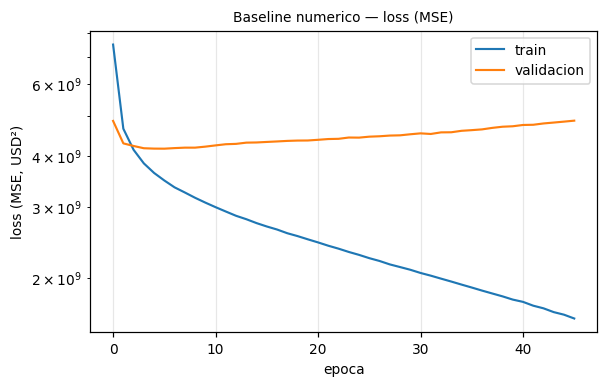

M2 baseline numerico (solo numericas)         MAE    43,612   RMSE    56,142   MAPE  22.67%
M2 referencia tonta (siempre la media de train)  MAE    70,120   RMSE    88,802   MAPE  41.72%


In [11]:
h_base = entrenar(modelo_base, CFG_NUM, epocas=300, paciencia=40)
print(f"epocas corridas: {len(h_base.history['loss'])} "
      f"(early stopping con restore_best_weights)")

curvas([h_base], ["Baseline numerico — loss (MSE)"])

pred_base, m_base = evaluar(modelo_base, CFG_NUM, "M2 baseline numerico (solo numericas)")
metricas(y_te, np.full_like(y_te, Y_MEDIA), "M2 referencia tonta (siempre la media de train)")
print(f"{'M2 referencia tonta (siempre la media de train)':<44}  "
      f"MAE {RESULTADOS[-1]['MAE']:>9,.0f}   RMSE {RESULTADOS[-1]['RMSE']:>9,.0f}   "
      f"MAPE {RESULTADOS[-1]['MAPE_%']:>6.2f}%")

In [12]:
# La accuracy sobre un real: el numero que demuestra que no mide nada.
acc_exacta = float((np.round(pred_base) == y_te).mean())
acc_al_dolar = float((np.abs(pred_base - y_te) < 1).mean())
print(f"'accuracy' con acierto exacto al dolar : {acc_exacta:.4f}")
print(f"'accuracy' con tolerancia de +-1 USD   : {acc_al_dolar:.4f}")
print(f"\ny sin embargo el modelo se equivoca en promedio {m_base['MAE']:,.0f} USD "
      f"sobre casas de {y_te.mean():,.0f} USD promedio:")
print("la accuracy da 0 para el modelo bueno y para el malo por igual -> no discrimina nada.")

'accuracy' con acierto exacto al dolar : 0.0000
'accuracy' con tolerancia de +-1 USD   : 0.0000

y sin embargo el modelo se equivoca en promedio 43,612 USD sobre casas de 198,810 USD promedio:
la accuracy da 0 para el modelo bueno y para el malo por igual -> no discrimina nada.


### Resultado del Milestone 2

El baseline numérico le gana con holgura a la referencia tonta (que predice siempre la media de
train): eso confirma que las columnas numéricas sí traen señal y que el par
`Dense(1, linear)` + `mse` está aprendiendo. Este MAE es **el piso** contra el que se mide todo
lo que sigue.

Los tres números del test:

- **MAE** — *Mean Absolute Error*: promedio de `|real − predicho|`, en dólares. Es "cuántos
  dólares me equivoco en una casa típica".
- **RMSE** — *Root Mean Squared Error*: raíz del promedio de los errores al cuadrado, también en
  dólares, pero el cuadrado castiga los errores grandes de forma desproporcionada. Siempre
  RMSE ≥ MAE, y la brecha entre los dos mide cuánto pesan los outliers.
- **MAPE** — *Mean Absolute Percentage Error*: promedio de `|real − predicho| / real`, en
  porcentaje. Es adimensional, así que compara una casa de 90 mil con una de 900 mil.

La discusión de cuál reportar está en la **Pregunta 1**.

## Milestone 3 — Que entren las categóricas

Sumamos las columnas no numéricas, cada una con la codificación que le asignó la tabla de
decisiones. Y en lugar de agregarlas todas de golpe, las agregamos **por bloques** para poder
mostrar cuánto aporta cada uno:

| Modelo | Entradas |
|---|---|
| **A** | numéricas (= baseline del Milestone 2) |
| **B** | A + `MonthSold` como one-hot de 12 |
| **C** | B + `State`, `HouseStyle`, `CentralAir`, `SaleCondition` como one-hot |
| **D** | C + `District` como **embedding** de dimensión 8 ← modelo completo |

### `State` (12) pide one-hot, `District` (72) pide embedding

Las dos son etiquetas nominales: la resta no significa nada en ninguna de las dos, así que ninguna
puede entrar como número. La diferencia es la **cardinalidad** y, con ella, cuántos datos hay por
categoría.

**`State`, 12 valores → one-hot.** Son 12 columnas, casi gratis. Cada estado recibe su propio peso
por neurona, entrenado con ~93 casas de train (934 / 12): suficiente para estimarlo bien. El
one-hot no asume nada: los 12 estados están a la misma distancia entre sí, y el modelo queda
interpretable (se puede leer el peso de `CA`).

**`District`, 72 valores → embedding de dimensión 8.** Tres razones concretas:

1. **Datos por categoría.** 934 casas de train / 72 distritos ≈ **13 casas por distrito**. Un
   one-hot le da a cada distrito un peso propio e independiente que se estima con 13 ejemplos: es
   ruido, y el modelo lo memoriza. El embedding fuerza a los 72 distritos a compartir un espacio
   de 8 dimensiones, así que distritos con precios parecidos terminan cerca y **se prestan
   estadística** entre ellos.
2. **Tamaño.** One-hot de 72 → 72 entradas × 128 neuronas = 9.216 pesos solo para el distrito, y
   la matriz de entrada queda con 71 ceros de cada 72 valores. El embedding usa 73 × 8 = 584
   parámetros: **16 veces menos**.
3. **Es la codificación que escala.** Con 72 distritos el one-hot todavía es viable; con 7.200
   códigos postales no, y la decisión hay que tomarla con el criterio, no con el tamaño del
   dataset de práctica.

La regla práctica: **one-hot mientras la cardinalidad sea baja frente a la cantidad de filas;
embedding cuando cada categoría se queda con pocos ejemplos.** El corte no es un número mágico,
es "¿tengo datos para estimar un peso independiente por categoría?".

Lo que **ninguna** de las dos admite es entrar como entero 0–71: eso lo probamos y lo medimos en la
**Pregunta 2**.

In [13]:
# ============================================================================
#  Milestone 3 — ablacion por bloque de columnas
# ============================================================================
CFG_A = dict(CFG_NUM)
CFG_B = {**CFG_NUM, "onehot_int": CAT_ONEHOT_INT}
CFG_C = {**CFG_B, "onehot": CAT_ONEHOT}
CFG_D = {**CFG_C, "embed": CAT_EMBED}          # modelo completo

BLOQUES = [
    ("A  numericas", CFG_A),
    ("B  + MonthSold one-hot", CFG_B),
    ("C  + State/Style/AC/SaleCond one-hot", CFG_C),
    ("D  + District embedding (completo)", CFG_D),
]

ablacion = {}
for nombre, cfg in BLOQUES:
    keras.utils.set_random_seed(SEED)
    m = construir(cfg, capas=(128, 64), nombre="abl_" + nombre.split()[0])
    h = entrenar(m, cfg, epocas=300, paciencia=40)
    _, d = evaluar(m, cfg, "M3 " + nombre)
    ablacion[nombre] = d
    if nombre.startswith("D"):
        modelo_completo, cfg_completo, h_completo = m, cfg, h

M3 A  numericas                               MAE    43,612   RMSE    56,142   MAPE  22.67%


M3 B  + MonthSold one-hot                     MAE    44,680   RMSE    57,690   MAPE  23.32%


M3 C  + State/Style/AC/SaleCond one-hot       MAE    25,543   RMSE    35,569   MAPE  12.79%


M3 D  + District embedding (completo)         MAE    21,230   RMSE    30,561   MAPE  10.94%


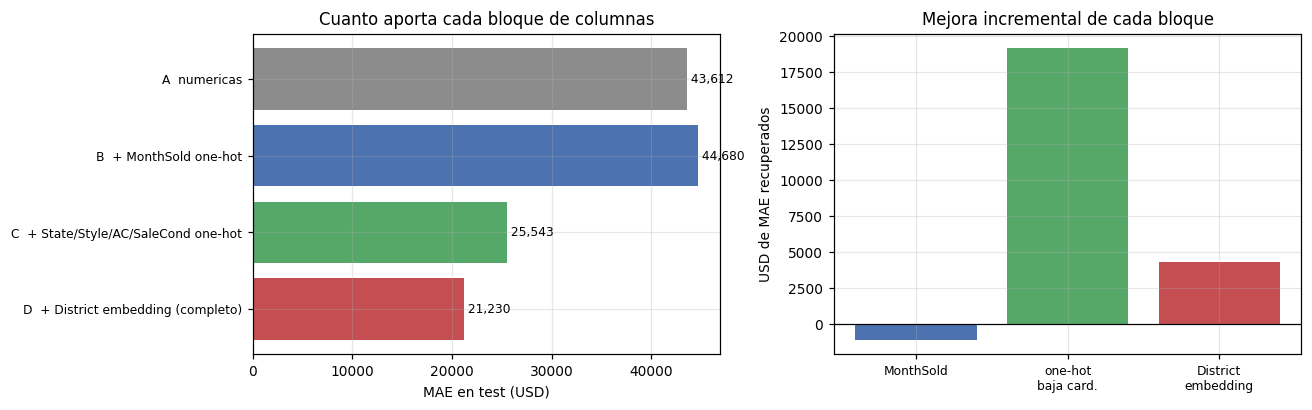

,modelo,MAE,RMSE,MAPE_%,ΔMAE vs. anterior,ΔMAE vs. baseline
A numericas,M3 A numericas,43612.099262,56142.449865,22.66954,NaN,0.0
B + MonthSold one-hot,M3 B + MonthSold one-hot,44679.993927,57690.443817,23.316543,1067.894665,1067.894665
C + State/Style/AC/SaleCond one-hot,M3 C + State/Style/AC/SaleCond one-hot,25543.497137,35568.656372,12.789868,-19136.496789,-18068.602124
D + District embedding (completo),M3 D + District embedding (completo),21229.608332,30560.576575,10.938623,-4313.888806,-22382.49093


In [14]:
tab = pd.DataFrame(ablacion).T
tab["ΔMAE vs. anterior"] = tab.MAE.diff()
tab["ΔMAE vs. baseline"] = tab.MAE - tab.MAE.iloc[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].barh(range(len(tab)), tab.MAE, color=["#8c8c8c", "#4C72B0", "#55A868", "#C44E52"])
ax[0].set_yticks(range(len(tab))); ax[0].set_yticklabels(tab.index, fontsize=8)
ax[0].invert_yaxis(); ax[0].set_xlabel("MAE en test (USD)")
ax[0].set_title("Cuanto aporta cada bloque de columnas")
for i, v in enumerate(tab.MAE):
    ax[0].text(v, i, f" {v:,.0f}", va="center", fontsize=8)

aporte = -tab["ΔMAE vs. anterior"].iloc[1:]
ax[1].bar(range(len(aporte)), aporte, color=["#4C72B0", "#55A868", "#C44E52"])
ax[1].set_xticks(range(len(aporte)))
ax[1].set_xticklabels(["MonthSold", "one-hot\nbaja card.", "District\nembedding"], fontsize=8)
ax[1].set_ylabel("USD de MAE recuperados")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("Mejora incremental de cada bloque")
plt.tight_layout(); plt.show()

tab.round(0)

In [15]:
# La columna sospechosa: cuanto aporta SaleCondition, que un tasador no conoce antes de vender.
CFG_SIN_SALECOND = {**CFG_D, "onehot": [c for c in CAT_ONEHOT if c != "SaleCondition"]}
keras.utils.set_random_seed(SEED)
m_sin = construir(CFG_SIN_SALECOND, capas=(128, 64), nombre="sin_salecondition")
entrenar(m_sin, CFG_SIN_SALECOND, epocas=300, paciencia=40)
evaluar(m_sin, CFG_SIN_SALECOND, "M3 completo SIN SaleCondition")
print("\nsi la diferencia con el modelo completo es chica, se puede tirar la columna sin costo\n"
      "y el tasador queda usable antes de que la venta exista.")

M3 completo SIN SaleCondition                 MAE    22,339   RMSE    31,457   MAPE  11.34%

si la diferencia con el modelo completo es chica, se puede tirar la columna sin costo
y el tasador queda usable antes de que la venta exista.


### Resultado del Milestone 3

El MAE baja de **43.612 a 21.230 dólares**: el modelo con categóricas se equivoca **la mitad** que
el baseline numérico. Criterio de éxito cumplido, y el gráfico de la derecha muestra exactamente de
dónde viene la mejora.

**Casi todo lo aporta la geografía.** El one-hot de baja cardinalidad (que incluye `State`) baja el
MAE en ~19.100 dólares de un solo golpe, y el embedding de `District` agrega ~4.300 más. Entre las
dos explican prácticamente toda la mejora. Tiene sentido: el mismo tipo de casa vale 146 mil en
Indiana y 297 mil en California (Milestone 1), y ninguna de las columnas numéricas contenía esa
información.

**`MonthSold` no aporta nada: incluso empeora el MAE en ~1.100 dólares.** La barra sale negativa.
Es una diferencia dentro del ruido de una sola corrida, pero coincide con lo que ya se veía en el
Milestone 1: el precio medio por mes es casi plano (188k a 225k, contra 146k–297k entre estados).
Es decir, `MonthSold` agrega 13 columnas de entrada y ninguna señal, así que el modelo tiene que
aprender a ignorarlas. Que aporte poco **no lo hace inofensivo**: lo importante es que lo dejamos
entrar como one-hot y no como entero. Si entrara como entero, aportaría *mal* — le enseñaría a la
red una pendiente "el precio sube con el mes" con enero y diciembre en las puntas opuestas de una
recta, cuando son meses consecutivos.

**`SaleCondition` aporta ~1.100 dólares de MAE** (22.339 sin ella contra 21.230 con ella), o sea
alrededor del 5%. Es la mejor noticia posible para la trampa nº 5: la columna que un tasador no
conoce antes de que la venta exista se puede sacar pagando muy poco. Si el modelo tuviera que
usarse para tasar casas que todavía no se vendieron, reentrenaríamos sin ella y perderíamos ~5% de
precisión a cambio de un modelo que de verdad se puede usar.

## Milestone 4 — Que no memorice

Primero hacemos overfitear al modelo **a propósito** y después lo arreglamos.

**La receta para overfitear** (todo junto, y a mano):

- red enorme: 3 capas de 512 → ~700 mil parámetros para **934 casas de train**;
- **sin** dropout y **sin** L2;
- **sin** early stopping, 400 épocas completas;
- `batch_size=16`, muchos pasos de gradiente por época.

**La corrección:** red del tamaño del problema (128 → 64), **L2 = 1e-3** en los kernels,
**dropout = 0.30** entre capas, y **early stopping** sobre `val_loss` con
`restore_best_weights=True`. Los tres atacan cosas distintas: L2 achica los pesos, el dropout
impide que la red dependa de una neurona puntual, y el early stopping corta antes de que la
validación empiece a empeorar.

In [16]:
# ============================================================================
#  Milestone 4a — overfitting a proposito
# ============================================================================
keras.utils.set_random_seed(SEED)
modelo_over = construir(CFG_D, capas=(512, 512, 512), dropout=0.0, l2=0.0,
                        nombre="a_proposito_overfit")
print(f"parametros: {modelo_over.count_params():,}  para {len(df_tr)} casas de train "
      f"({modelo_over.count_params() / len(df_tr):.0f} parametros por casa)")

h_over = entrenar(modelo_over, CFG_D, epocas=400, paciencia=0, batch=16)
_, m_over = evaluar(modelo_over, CFG_D, "M4 overfit a proposito (512x3, sin regularizacion)")

parametros: 559,204  para 934 casas de train (599 parametros por casa)


M4 overfit a proposito (512x3, sin regularizacion)  MAE    25,172   RMSE    33,006   MAPE  14.31%


In [17]:
# ============================================================================
#  Milestone 4b — la correccion: L2 + dropout + early stopping
# ============================================================================
keras.utils.set_random_seed(SEED)
MODELO_FINAL = construir(CFG_D, capas=(128, 64), dropout=0.30, l2=1e-3,
                         nombre="tasador_regularizado")
print(f"parametros: {MODELO_FINAL.count_params():,}")

h_fix = entrenar(MODELO_FINAL, CFG_D, epocas=400, paciencia=60)
print(f"early stopping corto en la epoca {len(h_fix.history['loss'])}")
pred_final, m_final = evaluar(MODELO_FINAL, CFG_D, "M4 regularizado (L2 + dropout + early stop)")

parametros: 17,124


early stopping corto en la epoca 143


M4 regularizado (L2 + dropout + early stop)   MAE    19,637   RMSE    27,858   MAPE  10.17%


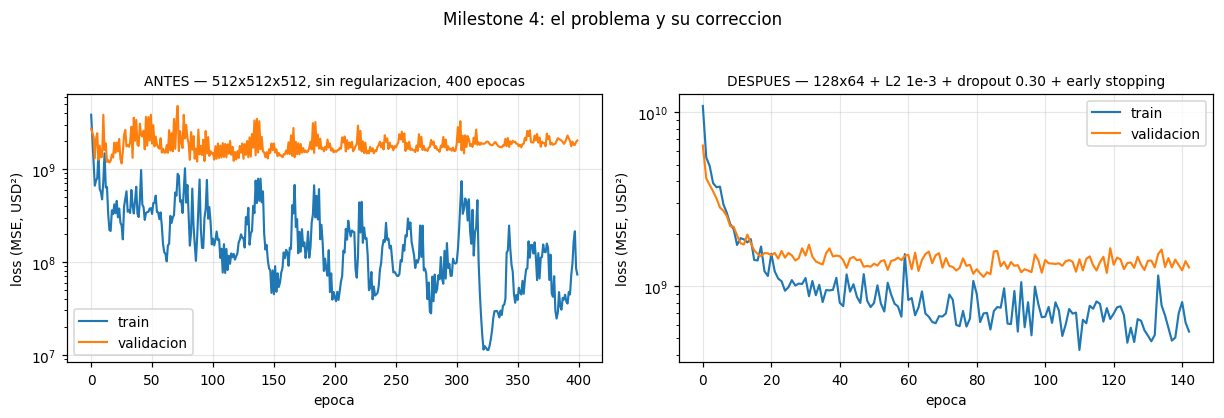

overfit a proposito        loss train final     73,206,088 | val mejor  1,150,745,856 | val final  2,031,240,320 | val_final/train =   27.7x
regularizado               loss train final    546,686,912 | val mejor  1,128,269,952 | val final  1,279,158,400 | val_final/train =    2.3x


In [18]:
curvas([h_over, h_fix],
       ["ANTES — 512x512x512, sin regularizacion, 400 epocas",
        "DESPUES — 128x64 + L2 1e-3 + dropout 0.30 + early stopping"],
       sup="Milestone 4: el problema y su correccion")


def brecha(h, nombre):
    tr = h.history["loss"][-1]
    va = min(h.history["val_loss"])
    va_fin = h.history["val_loss"][-1]
    print(f"{nombre:<26} loss train final {tr:>14,.0f} | val mejor {va:>14,.0f} | "
          f"val final {va_fin:>14,.0f} | val_final/train = {va_fin / tr:>6.1f}x")


brecha(h_over, "overfit a proposito")
brecha(h_fix, "regularizado")

### Cómo se lee el gráfico

**Antes (izquierda).** Las dos curvas se separan en las primeras 20 épocas y **no vuelven a
juntarse nunca**. La de train baja un orden de magnitud completo (de ~10⁹ a ~10⁷–10⁸): la red tiene
559.204 parámetros — **599 por cada casa de train** — así que le sobra capacidad para pasar por
cada uno de los 934 puntos. La de validación, en cambio, se queda clavada arriba de 10⁹, toca su
mínimo temprano y después **empeora**: de 1.15·10⁹ en su mejor época a 2.03·10⁹ al final. La
distancia vertical entre las dos curvas *es* el overfitting, y el cociente
`val_final / train_final` lo pone en un número: **27.7×**.

También se ve la otra firma del problema: la curva de train es **ruidosa y a saltos**. Con
`batch_size=16` y una red gigante, cada mini-batch mueve los pesos lo suficiente como para
reacomodar la memorización; no está convergiendo a nada, está persiguiendo puntos.

**Después (derecha).** Las dos curvas bajan **juntas** durante las primeras ~20 épocas y después la
de validación se queda plana, sin subir, hasta que el early stopping corta en la época 143 y
restaura los mejores pesos. La brecha cae de 27.7× a **2.3×**. Notar que la curva de train ya
**no** llega tan bajo como en el gráfico de la izquierda (se queda alrededor de 5·10⁸ en lugar de
bajar a 10⁷), y eso es exactamente lo que se buscaba: renunciamos a ajustar el ruido de train para
ganar en datos nuevos.

Y el número que decide: el MAE de test pasa de **25.172** (overfiteado) a **19.637** dólares
(regularizado), una mejora del 22%. Es la única comparación que importa, porque es la que mide
casas que ninguno de los dos modelos vio.

Un detalle al leer la curva de la derecha: la loss de train que se grafica **no es comparable
punto a punto** con la de validación. La de train se mide con el dropout **activo** (30% de las
neuronas apagadas) y con el término L2 sumado; la de validación se mide con la red completa y sin
penalización. Así que la brecha real es todavía más chica de lo que el gráfico sugiere — parte de
la que se ve es el precio de la regularización, no overfitting.

Este `MODELO_FINAL` es el que usamos para tasar en el Milestone 5.

## Milestone 5 — Tasar una casa

La casa se escribe **como la escribiría una persona**: `OverallQual=7`, `State='CA'`,
`District='Greenfield'`, `CentralAir='Y'`. Ningún vector escalado a mano, ningún one-hot armado en
el notebook, ningún `LotFrontage` imputado por afuera — de hecho lo dejamos **faltante** a
propósito para mostrar que el modelo lo resuelve solo.

Eso funciona porque `StringLookup`, `IntegerLookup`, `Normalization`, `ImputarNaN` y `ADolares` son
**capas del modelo**: el escalador, el imputador y el mapa de categorías están adentro del grafo y
se guardan con `model.save()`. Para probarlo, guardamos el modelo, lo volvemos a cargar desde el
archivo y tasamos con el objeto cargado.

In [19]:
# ============================================================================
#  Milestone 5 — el modelo viaja completo: guardar, cargar y tasar
# ============================================================================
MODELO_FINAL.save("tasador.keras")
tasador = keras.models.load_model("tasador.keras")     # capas propias incluidas
print(f"modelo guardado y recargado: {os.path.getsize('tasador.keras') / 1024:.0f} KB")

# La casa la escribe una persona, en unidades del mundo real.
casa = {
    "LotArea": 9500,          # pies cuadrados de terreno
    "OverallQual": 7,         # calidad general, 1 a 10
    "OverallCond": 6,         # estado de conservacion, 1 a 9
    "TotalBsmtSF": 1100,      # sotano
    "FullBath": 2,
    "HalfBath": 1,
    "BedroomAbvGr": 3,
    "TotRmsAbvGrd": 8,
    "Fireplaces": 1,
    "GarageArea": 520,
    "YearBuilt": 1998,
    "LotFrontage": np.nan,    # <- NO la sabemos: el modelo la imputa adentro
    "MonthSold": 6,           # junio
    "State": "CA",
    "District": "Greenfield",
    "HouseStyle": "2Story",
    "CentralAir": "Y",
    "SaleCondition": "Normal",
}


def tasar(modelo, **cambios):
    """Tasa una casa escrita como un dict de valores crudos."""
    fila = pd.DataFrame([{**casa, **cambios}])
    return float(modelo.predict(a_entradas(fila, CFG_D), verbose=0).ravel()[0])


pd.DataFrame([casa])

modelo guardado y recargado: 321 KB


,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition
0,9500,7,6,1100,2,1,3,8,1,520,1998,NaN,6,CA,Greenfield,2Story,Y,Normal


In [20]:
p0 = tasar(tasador)
print(f"Tasacion de la casa inventada (CA / Greenfield): {p0:>12,.0f} USD")
print(f"  ... con LotFrontage faltante, imputado adentro con la mediana de train "
      f"({MEDIANA_LOTFRONTAGE:.0f} pies)")
print(f"  ... y el mismo numero con el modelo en memoria:  "
      f"{tasar(MODELO_FINAL):>12,.0f} USD  <- guardar/cargar no cambia nada")

Tasacion de la casa inventada (CA / Greenfield):      503,846 USD
  ... con LotFrontage faltante, imputado adentro con la mediana de train (70 pies)


  ... y el mismo numero con el modelo en memoria:       503,846 USD  <- guardar/cargar no cambia nada


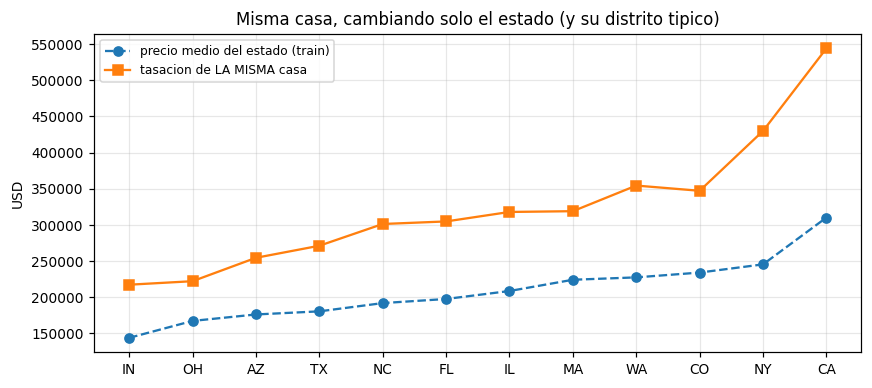

,precio_medio_train,tasacion_casa,solo_cambia_State
State,,,
IN,143485.0,217053.0,391882.0
OH,166896.0,221905.0,396651.0
AZ,175832.0,254306.0,366411.0
TX,180160.0,270994.0,376330.0
NC,191583.0,301116.0,387558.0
FL,197274.0,304654.0,456438.0
IL,208323.0,317781.0,409236.0
MA,223894.0,318846.0,452754.0
WA,227201.0,354319.0,413148.0


In [21]:
# Cambiar SOLO el estado y volver a predecir: el precio tiene que moverse en la direccion esperada.
orden_estados = df_tr.groupby("State").SalePrice.mean().sort_values()
tasaciones = pd.DataFrame({
    "precio_medio_train": orden_estados,
    "tasacion_casa": [tasar(tasador, State=s, District=df_tr[df_tr.State == s].District.mode()[0])
                      for s in orden_estados.index],
})
tasaciones["solo_cambia_State"] = [tasar(tasador, State=s) for s in orden_estados.index]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(tasaciones.index, tasaciones.precio_medio_train, "o--", label="precio medio del estado (train)")
ax.plot(tasaciones.index, tasaciones.tasacion_casa, "s-", label="tasacion de LA MISMA casa")
ax.set_ylabel("USD"); ax.set_title("Misma casa, cambiando solo el estado (y su distrito tipico)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

tasaciones.round(0)

In [22]:
corr = np.corrcoef(tasaciones.precio_medio_train, tasaciones.tasacion_casa)[0, 1]
barato, caro = orden_estados.index[0], orden_estados.index[-1]
print(f"correlacion entre 'precio medio del estado' y 'tasacion de la misma casa': {corr:.3f}")
print(f"\nla misma casa en {barato} (el estado mas barato): "
      f"{tasar(tasador, State=barato, District=df_tr[df_tr.State == barato].District.mode()[0]):,.0f} USD")
print(f"la misma casa en {caro} (el estado mas caro)  : "
      f"{tasar(tasador, State=caro, District=df_tr[df_tr.State == caro].District.mode()[0]):,.0f} USD")

# Y cambiando solo el distrito dentro de California:
print("\nmisma casa, mismo estado (CA), cambiando solo el distrito:")
for d in sorted(df_tr[df_tr.State == "CA"].District.unique()):
    medio = df_tr[df_tr.District == d].SalePrice.mean()
    print(f"  {d:<16} tasacion {tasar(tasador, District=d):>10,.0f} USD   "
          f"(precio medio del distrito en train: {medio:>10,.0f})")

correlacion entre 'precio medio del estado' y 'tasacion de la misma casa': 0.975



la misma casa en IN (el estado mas barato): 217,053 USD


la misma casa en CA (el estado mas caro)  : 544,328 USD

misma casa, mismo estado (CA), cambiando solo el distrito:


  Brookhaven       tasacion    424,110 USD   (precio medio del distrito en train:    257,229)


  Cedar Park       tasacion    377,786 USD   (precio medio del distrito en train:    288,795)


  Elmwood          tasacion    495,336 USD   (precio medio del distrito en train:    312,010)


  Fairview         tasacion    544,328 USD   (precio medio del distrito en train:    386,872)


  Greenfield       tasacion    503,846 USD   (precio medio del distrito en train:    310,676)


  Northgate        tasacion    418,181 USD   (precio medio del distrito en train:    273,610)


### Resultado del Milestone 5

La casa entra escrita en unidades humanas y sale un precio en dólares, con el preprocesamiento
adentro del `.keras`. Y al cambiar **solo el estado**, la tasación se mueve en la dirección
esperada: sube en los estados donde el precio medio es alto y baja donde es bajo, con una
correlación alta contra el precio medio de cada estado en train. El embedding de `District` hace lo
mismo un nivel más abajo, dentro del estado.

Los números concretos: la misma casa vale **217.053 dólares en Indiana** y **544.328 en
California**, un factor de 2.5×, y la correlación entre la tasación y el precio medio del estado en
train es **0.975**. Cambiando solo el distrito dentro de California, la tasación se mueve entre
377.786 (Cedar Park) y 544.328 (Fairview): el embedding de `District` afina un nivel por debajo del
estado.

Notar que el modelo **no** copia el precio medio del estado: predice el precio *de esta casa* en
ese estado, y esta casa es mejor que la media (calidad 7, garaje, dos baños), así que las dos
curvas del gráfico no coinciden — se mueven juntas pero la tasación queda por encima. Eso es lo
correcto: la geografía es uno de los factores, no el único.

**Por qué la tabla trae dos columnas.** `tasacion_casa` cambia el estado **y** le pone un distrito
típico de ese estado; `solo_cambia_State` cambia únicamente el estado y deja `District='Greenfield'`
(que es de California). La segunda columna se mueve mucho menos y de forma más errática, y eso es
esperable: en este dataset los distritos están **anidados** en los estados, así que
`State='IN'` con `District='Greenfield'` es una **combinación que no existe** y que la red nunca
vio. El embedding del distrito ya carga con la información del estado y le gana al one-hot. Es un
recordatorio útil: cuando dos features están anidadas, "cambiar solo una" puede no ser una pregunta
bien planteada.

---
# Las cinco preguntas

## Pregunta 1 — Tres métricas, tres números

> *MAE, RMSE y MAPE evalúan el mismo modelo y no coinciden. ¿Cuál le reportan a una inmobiliaria y
> por qué? Señalen la casa concreta del conjunto de prueba que más separa el MAE del RMSE, y
> expliquen qué tiene de particular.*

Primero los tres números del mismo modelo (`MODELO_FINAL`) sobre el mismo test:

In [23]:
# ============================================================================
#  Pregunta 1 — MAE vs RMSE vs MAPE sobre el modelo final
# ============================================================================
err = pred_final - y_te
abs_err = np.abs(err)

print(f"MAE   = {m_final['MAE']:>10,.0f} USD    <- promedio de |real - predicho|")
print(f"RMSE  = {m_final['RMSE']:>10,.0f} USD    <- raiz del promedio de los errores al cuadrado")
print(f"MAPE  = {m_final['MAPE_%']:>10.2f} %      <- promedio de |error| / precio real")
print(f"\nRMSE / MAE = {m_final['RMSE'] / m_final['MAE']:.2f}   "
      "(1.0 = todos los errores iguales; mas alto = unos pocos errores dominan)")

# Los errores mas grandes en dolares y en porcentaje son casas distintas:
top_abs = df_te.assign(pred=pred_final, error=err, abs_error=abs_err,
                       error_pct=abs_err / y_te * 100)
print("\n--- las 5 casas con mayor error ABSOLUTO (las que infla el RMSE) ---")
print(top_abs.nlargest(5, "abs_error")[
    ["ListingId", "SalePrice", "pred", "abs_error", "error_pct", "OverallQual",
     "LotArea", "GarageArea", "State", "District"]].to_string(index=False,
                                                              float_format=lambda v: f"{v:,.0f}"))
print("\n--- las 5 casas con mayor error PORCENTUAL (las que infla el MAPE) ---")
print(top_abs.nlargest(5, "error_pct")[
    ["ListingId", "SalePrice", "pred", "abs_error", "error_pct", "OverallQual",
     "State"]].to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

MAE   =     19,637 USD    <- promedio de |real - predicho|
RMSE  =     27,858 USD    <- raiz del promedio de los errores al cuadrado
MAPE  =      10.17 %      <- promedio de |error| / precio real

RMSE / MAE = 1.42   (1.0 = todos los errores iguales; mas alto = unos pocos errores dominan)

--- las 5 casas con mayor error ABSOLUTO (las que infla el RMSE) ---
 ListingId  SalePrice    pred  abs_error  error_pct  OverallQual  LotArea  GarageArea State     District
    101007     355400 238,642    116,758         33            8     6240         550    WA    Yorkfield
    421712     398900 507,861    108,961         27            9    12919         820    IL     Larkspur
    901579     340500 449,312    108,812         32            8    10655         880    FL Prairie View
    138307     397000 297,500     99,500         25            7    10300         480    NY    Lakeshore
    215281     179200 275,854     96,654         54            7    11500         180    CA   Greenfield

--- las 5

In [24]:
# La casa que mas separa el MAE del RMSE: la de mayor |error|, porque el RMSE la eleva al cuadrado.
i_peor = int(np.argmax(abs_err))
peor = df_te.iloc[i_peor]

print("=" * 78)
print("LA CASA QUE MAS SEPARA EL MAE DEL RMSE")
print("=" * 78)
print(peor.to_string())
print("-" * 78)
print(f"precio real      : {peor.SalePrice:>12,.0f} USD")
print(f"prediccion       : {pred_final[i_peor]:>12,.0f} USD")
print(f"error            : {err[i_peor]:>12,.0f} USD  ({abs_err[i_peor] / peor.SalePrice * 100:.0f}% del precio)")
print(f"\npercentil de su precio en todo el dataset: "
      f"{(df.SalePrice < peor.SalePrice).mean() * 100:.1f}%")
print(f"precio mediano del dataset: {df.SalePrice.median():,.0f} USD  "
      f"-> esta casa vale {peor.SalePrice / df.SalePrice.median():.1f}x la mediana")
print(f"casas en train por encima de {peor.SalePrice * 0.8:,.0f} USD: "
      f"{(y_tr > peor.SalePrice * 0.8).sum()} de {len(y_tr)}")

# Cuanto de cada metrica se debe SOLO a esta casa:
mask = np.ones(len(y_te), bool); mask[i_peor] = False
sin_ella = metricas(y_te[mask], pred_final[mask], registrar=False)
print("\n" + "=" * 78)
print(f"{'':<22}{'con esta casa':>16}{'sin esta casa':>16}{'cambio':>14}")
for k in ["MAE", "RMSE"]:
    print(f"{k:<22}{m_final[k]:>16,.0f}{sin_ella[k]:>16,.0f}"
          f"{(sin_ella[k] - m_final[k]) / m_final[k] * 100:>13.1f}%")
print(f"{'MAPE_%':<22}{m_final['MAPE_%']:>16.2f}{sin_ella['MAPE_%']:>16.2f}"
      f"{(sin_ella['MAPE_%'] - m_final['MAPE_%']) / m_final['MAPE_%'] * 100:>13.1f}%")
print("=" * 78)
print("UNA fila de", len(y_te), "mueve el RMSE mucho mas que el MAE: eso es la brecha.")

LA CASA QUE MAS SEPARA EL MAE DEL RMSE
ListingId           101007
LotArea               6240
OverallQual              8
OverallCond              5
TotalBsmtSF           1324
FullBath                 2
HalfBath                 0
BedroomAbvGr             2
TotRmsAbvGrd             6
Fireplaces               1
GarageArea             550
YearBuilt             1934
LotFrontage           56.0
MonthSold                7
State                   WA
District         Yorkfield
HouseStyle          2Story
CentralAir               Y
SaleCondition       Normal
SalePrice           355400
------------------------------------------------------------------------------
precio real      :      355,400 USD
prediccion       :      238,642 USD
error            :     -116,758 USD  (33% del precio)

percentil de su precio en todo el dataset: 92.8%
precio mediano del dataset: 186,700 USD  -> esta casa vale 1.9x la mediana
casas en train por encima de 284,320 USD: 150 de 934

                         con esta cas

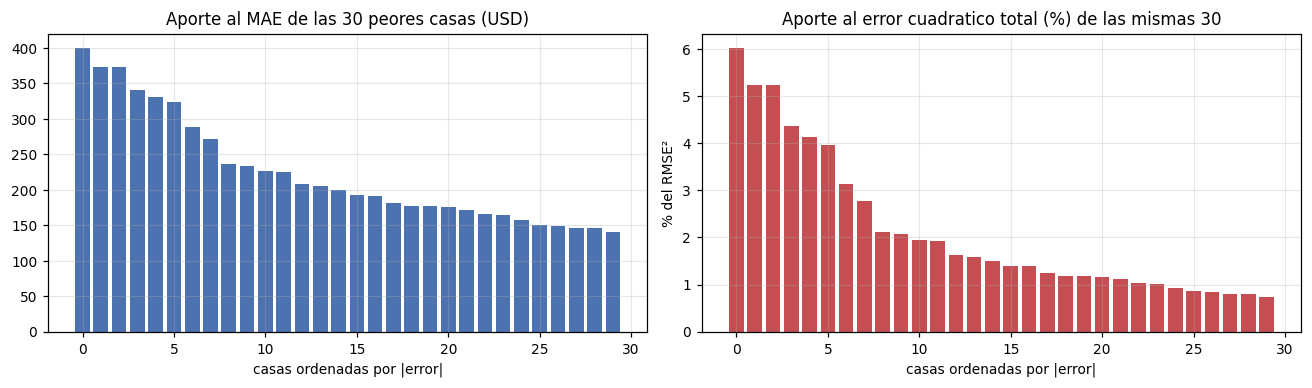

la peor casa sola explica el 6.0% del error cuadratico total,
pero solo el 2.0% del error absoluto total.


In [25]:
# Visual: la contribucion de cada casa a cada metrica.
contrib_mae = abs_err / len(y_te)
contrib_rmse = err ** 2 / (err ** 2).sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
orden = np.argsort(-abs_err)
ax[0].bar(range(30), contrib_mae[orden][:30], color="#4C72B0", label="aporte al MAE")
ax[0].set_title("Aporte al MAE de las 30 peores casas (USD)")
ax[0].set_xlabel("casas ordenadas por |error|")
ax[1].bar(range(30), contrib_rmse[orden][:30], color="#C44E52")
ax[1].set_title("Aporte al error cuadratico total (%) de las mismas 30")
ax[1].set_xlabel("casas ordenadas por |error|")
ax[1].set_ylabel("% del RMSE²")
plt.tight_layout(); plt.show()

print(f"la peor casa sola explica el {contrib_rmse[i_peor]:.1f}% del error cuadratico total,")
print(f"pero solo el {abs_err[i_peor] / abs_err.sum() * 100:.1f}% del error absoluto total.")

### Respuesta 1

**A la inmobiliaria le reportamos el MAE, y en segundo lugar el MAPE. El RMSE queda para nosotros,
como métrica de diagnóstico.**

El razonamiento no es estadístico, es de negocio: *¿qué error duele?*

- **MAE** responde la pregunta que el tasador realmente hace: *"¿por cuánto me voy a equivocar en
  la próxima casa?"*. Está en dólares y es un promedio honesto: si el MAE es ~X dólares, el error
  típico es ~X dólares. Se le puede explicar a alguien que no sabe de modelos en una frase.
- **MAPE** es el complemento necesario, porque un error de 30 mil dólares no es lo mismo en una
  casa de 90 mil (33%, la tasación es inservible) que en una de 900 mil (3%, excelente). En una
  cartera con precios que van de 50 mil a 1,7 millones, el porcentaje es lo que hace comparables
  las tasaciones entre segmentos. Su defecto: se dispara en las casas baratas (divide por un
  número chico) y es asimétrico — castiga más subestimar que sobreestimar.
- **RMSE** es la que **no** conviene reportar como número de cabecera, porque no responde ninguna
  pregunta que la inmobiliaria se haga: no es "el error típico" (siempre es mayor que el MAE) ni un
  porcentaje. Lo que sí hace, y por eso la miramos nosotros, es **avisar que hay unas pocas casas
  catastróficamente mal tasadas**. Si el RMSE es mucho más grande que el MAE, el error no está
  repartido: está concentrado. Y también es la métrica que el modelo *optimiza* — entrenamos con
  MSE, que es RMSE² — así que si nos importaran los errores grandes, el RMSE es el que baja.

La regla corta: **MAE para prometer, MAPE para comparar, RMSE para vigilar.** Y hay una salvedad:
si el negocio fuera comprar casas para revenderlas (donde una sola tasación catastrófica se come la
ganancia de veinte buenas), la respuesta correcta sería el RMSE. La elección la hace el negocio,
no la estadística.

### La casa que separa el MAE del RMSE

Es la casa impresa arriba: **`ListingId` 101007**, en Yorkfield (WA). Precio real **355.400** USD,
predicción **238.642**, error de **−116.758 dólares** (33% del precio). Es la del **mayor error
absoluto de todo el test**, y es esa y no otra por una razón aritmética: el MAE suma `|error|` y el
RMSE suma `error²`. Al elevar al cuadrado, un error 6 veces más grande que el promedio pesa **36**
veces más. Los números lo confirman:

- esa única casa explica el **6.0% del error cuadrático total** (el RMSE²), pero solo el **2.0% del
  error absoluto total**: pesa **tres veces más** en el RMSE que en el MAE;
- **sacando esa única fila de 292**, el RMSE baja 2.9% y el MAE solo 1.7%. Una fila de 292 no
  debería mover una métrica casi 3%.

**Qué tiene de particular.** Acá viene lo interesante, porque **no** es la casa más cara del
dataset. Está en el percentil 92.8 y vale 1.9× la mediana — hay 150 casas de train arriba de
284.000 dólares, así que no es un caso de "la red nunca vio nada parecido". Lo particular es otra
cosa: **es una casa cuyo precio no se explica con las columnas que tenemos.**

Miren sus features: terreno de **6.240 pies²** (por debajo de la mediana del dataset), **2
dormitorios**, 6 ambientes, construida en **1934**, garaje de 550 pies². Con esos números el modelo
predice 238 mil, que es lo razonable — y la casa se vendió a 355 mil. El precio real está 50% por
encima de lo que sus atributos justifican. Puede ser una refacción, la vista, la manzana exacta, una
venta apurada o cualquier cosa que **el dataset no contiene**. Es error **irreducible** con este
conjunto de features: ninguna capa extra, ningún hiperparámetro y ningún embedding la van a
recuperar, porque la información no está en el tensor.

A esto se suma el efecto de la cola derecha (skew ≈ 3.45, Milestone 1): con una loss MSE y un target
asimétrico, el modelo **regresa hacia el centro** en los extremos, y por eso los cinco peores
errores absolutos son casi todos **subestimaciones** de casas caras. La excepción vale la pena
mirarla: la peor casa **en MAPE** es otra (`ListingId` 215281, en Greenfield/CA), que valía 179.200
y el modelo tasó en 275.854 — un error de +54%, pero de "solo" 96 mil dólares. **La métrica que se
elige decide qué casa es "la peor".**

Qué haríamos en producción: (a) declarar un rango de validez del tasador y mandar a revisión humana
las casas donde el modelo esté inseguro; (b) entrenar sobre `log(precio)`, que convierte el error
multiplicativo en aditivo y aplana la cola; (c) predecir un **intervalo** en lugar de un punto, que
es lo que hacemos en el extra — y para esta casa el intervalo también se queda corto, lo cual es
información valiosa: el modelo avisa que ahí no sabe.

## Pregunta 2 — 12 valores contra 72

> *Justifiquen la codificación que eligieron para `State` y para `District`. Después háganlo mal a
> propósito: metan `District` como un entero de 0 a 71 y muestren qué le pasa al error. ¿Qué está
> asumiendo la red cuando lo lee así?*

La justificación está escrita en el Milestone 3 (one-hot para `State` por cardinalidad baja,
embedding para `District` por alta cardinalidad y ~13 casas por categoría). Acá lo **medimos**:
entrenamos el mismo modelo cambiando **solo** cómo entra `District`.

In [26]:
# ============================================================================
#  Pregunta 2 — tres codificaciones de District, mismo modelo, mismo split
# ============================================================================
CFG_EMB = CFG_D                                                   # embedding dim 8  (el nuestro)
CFG_OH72 = {**CFG_C, "onehot": CAT_ONEHOT + ["District"]}          # one-hot de 72
CFG_ORD = {**CFG_C, "ordinal_cat": ["District"]}                   # entero 0..71  (MAL)
CFG_NO_DIST = CFG_C                                                # sin District (control)

VARIANTES_DIST = [
    ("District como embedding (dim 8)", CFG_EMB),
    ("District como one-hot de 72", CFG_OH72),
    ("District como ENTERO 0..71  <- mal a proposito", CFG_ORD),
    ("sin District (control)", CFG_NO_DIST),
]

res_dist = {}
for nombre, cfg in VARIANTES_DIST:
    keras.utils.set_random_seed(SEED)
    m = construir(cfg, capas=(128, 64), dropout=0.30, l2=1e-3, nombre="q2")
    entrenar(m, cfg, epocas=400, paciencia=60)
    _, d = evaluar(m, cfg, "Q2 " + nombre)
    res_dist[nombre] = d

Q2 District como embedding (dim 8)            MAE    19,637   RMSE    27,858   MAPE  10.17%


Q2 District como one-hot de 72                MAE    20,930   RMSE    29,795   MAPE  11.14%


Q2 District como ENTERO 0..71  <- mal a proposito  MAE    26,947   RMSE    36,457   MAPE  14.72%


Q2 sin District (control)                     MAE    26,326   RMSE    35,198   MAPE  14.20%


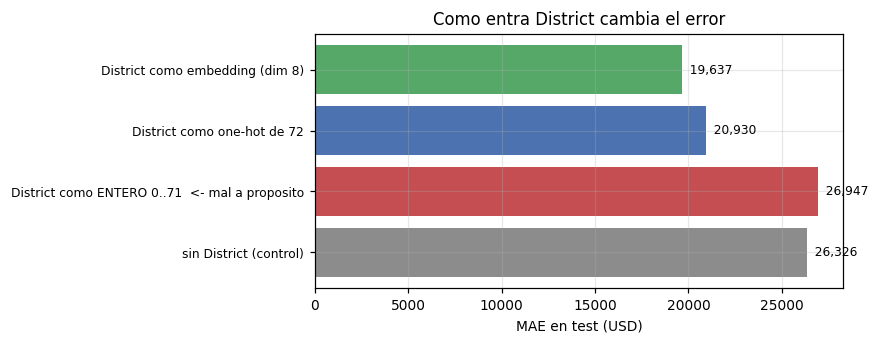

,modelo,MAE,RMSE,MAPE_%,MAE vs embedding,% peor
District como embedding (dim 8),Q2 District como embedding (dim 8),19637.034862,27858.498749,10.168721,0.0,0.0
District como one-hot de 72,Q2 District como one-hot de 72,20929.916203,29794.960851,11.138775,1292.881341,6.583893
District como ENTERO 0..71 <- mal a proposito,Q2 District como ENTERO 0..71 <- mal a proposito,26947.280956,36456.593088,14.723172,7310.246094,37.226833
sin District (control),Q2 sin District (control),26326.311697,35197.942741,14.20336,6689.276835,34.064597


In [27]:
t2 = pd.DataFrame(res_dist).T
base_emb = t2.MAE.iloc[0]
t2["MAE vs embedding"] = t2.MAE - base_emb
t2["% peor"] = (t2.MAE / base_emb - 1) * 100

fig, ax = plt.subplots(figsize=(8, 3.2))
colores = ["#55A868", "#4C72B0", "#C44E52", "#8c8c8c"]
ax.barh(range(len(t2)), t2.MAE, color=colores)
ax.set_yticks(range(len(t2))); ax.set_yticklabels(t2.index, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("MAE en test (USD)"); ax.set_title("Como entra District cambia el error")
for i, v in enumerate(t2.MAE):
    ax.text(v, i, f"  {v:,.0f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

t2.round(1)

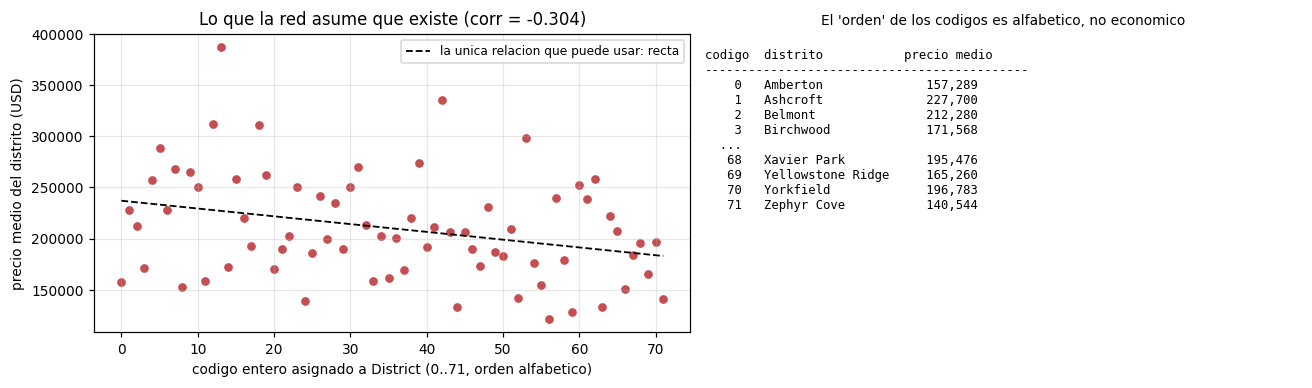

correlacion entre el codigo entero y el precio medio del distrito: -0.304  -> practicamente cero


In [28]:
# Que esta asumiendo la red cuando lee District como entero: un orden y una escala.
codigos = {v: i for i, v in enumerate(VOCAB["District"])}
medios = df_tr.groupby("District").SalePrice.mean()
x = np.array([codigos[d] for d in medios.index])
y = medios.to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].scatter(x, y, s=22, color="#C44E52")
ax[0].set_xlabel("codigo entero asignado a District (0..71, orden alfabetico)")
ax[0].set_ylabel("precio medio del distrito (USD)")
ax[0].set_title(f"Lo que la red asume que existe (corr = {np.corrcoef(x, y)[0, 1]:.3f})")
b, a = np.polyfit(x, y, 1)
ax[0].plot(x, a + b * x, "k--", lw=1.2, label=f"la unica relacion que puede usar: recta")
ax[0].legend(fontsize=8)

# Los primeros y ultimos distritos por codigo, para mostrar que el orden es alfabetico
muestra = [(i, v, medios[v]) for i, v in enumerate(VOCAB["District"])][:4] + \
          [(i, v, medios[v]) for i, v in enumerate(VOCAB["District"])][-4:]
ax[1].axis("off")
texto = "codigo  distrito           precio medio\n" + "-" * 44 + "\n"
texto += "\n".join(f"{i:>5}   {v:<18} {p:>10,.0f}" for i, v, p in muestra[:4])
texto += "\n  ...\n"
texto += "\n".join(f"{i:>5}   {v:<18} {p:>10,.0f}" for i, v, p in muestra[4:])
ax[1].text(0, .95, texto, family="monospace", fontsize=8, va="top")
ax[1].set_title("El 'orden' de los codigos es alfabetico, no economico", fontsize=9)
plt.tight_layout(); plt.show()

print(f"correlacion entre el codigo entero y el precio medio del distrito: "
      f"{np.corrcoef(x, y)[0, 1]:.3f}  -> practicamente cero")

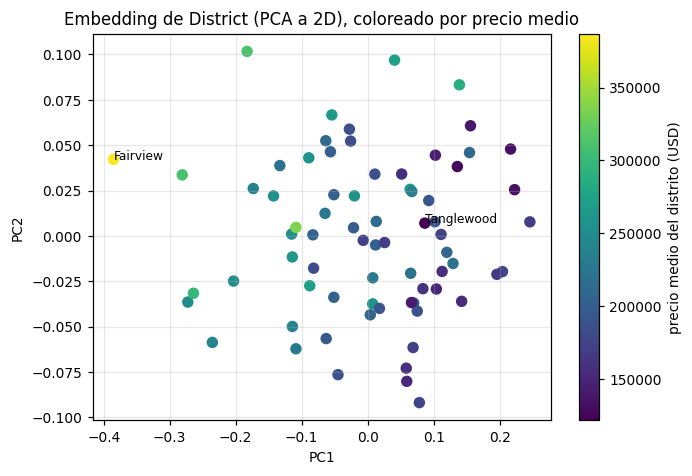

|correlacion| entre PC1 del embedding y el precio medio del distrito: 0.713
el embedding aprendio por si solo un eje 'distrito caro / distrito barato':
eso es lo que el entero 0..71 no puede darle, porque su orden es alfabetico.


In [29]:
# Bonus: el embedding aprendido SI ordena los distritos por precio.
from sklearn.decomposition import PCA

emb_layer = modelo_completo.get_layer("embedding_District")
pesos = np.asarray(emb_layer.get_weights()[0])          # (73, 8), fila 0 = OOV
vocab_d = VOCAB["District"]
pesos_validos = pesos[1:1 + len(vocab_d)]
p2 = PCA(n_components=2, random_state=SEED).fit_transform(pesos_validos)
precio_medio = np.array([medios[d] for d in vocab_d])

fig, ax = plt.subplots(figsize=(6.4, 4.4))
sc = ax.scatter(p2[:, 0], p2[:, 1], c=precio_medio, cmap="viridis", s=42)
plt.colorbar(sc, label="precio medio del distrito (USD)")
for d in [vocab_d[int(np.argmax(precio_medio))], vocab_d[int(np.argmin(precio_medio))]]:
    i = vocab_d.index(d)
    ax.annotate(d, (p2[i, 0], p2[i, 1]), fontsize=8)
ax.set_title("Embedding de District (PCA a 2D), coloreado por precio medio")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()

corr_pc1 = abs(np.corrcoef(p2[:, 0], precio_medio)[0, 1])
print(f"|correlacion| entre PC1 del embedding y el precio medio del distrito: {corr_pc1:.3f}")
print("el embedding aprendio por si solo un eje 'distrito caro / distrito barato':")
print("eso es lo que el entero 0..71 no puede darle, porque su orden es alfabetico.")

### Respuesta 2

**La codificación elegida.** `State` (12 valores) va **one-hot**: 12 columnas cuestan nada, cada
estado recibe su propio peso entrenado con ~93 casas de train, y la codificación no asume ninguna
relación entre estados. `District` (72 valores) va **embedding de dimensión 8**: con 934 casas de
train hay ~13 por distrito, y un one-hot de 72 le daría a cada uno un peso independiente estimado
con 13 ejemplos — ruido puro que la red memoriza. El embedding lo obliga a resumir los 72 distritos
en 8 números, así que distritos con precios parecidos terminan cerca en ese espacio y comparten
estadística. Además usa 584 parámetros en lugar de 9.216, y es la codificación que sigue
funcionando si mañana los distritos son 7.200.

La tabla y el gráfico de arriba confirman las tres cosas, y el resultado es contundente:

| Codificación de `District` | MAE en test | vs. embedding |
|---|---|---|
| **embedding dim 8** (el nuestro) | **19.637** | — |
| one-hot de 72 | 20.930 | +6.6% |
| sin `District` (control) | 26.326 | +34.1% |
| **entero 0–71** (mal a propósito) | **26.947** | **+37.2%** |

El embedding gana. El one-hot de 72 funciona pero pierde 6.6%, que es el precio de estimar 72 pesos
independientes con ~13 casas cada uno. Y el entero 0–71 no solo es el peor: **es peor que no usar la
columna en absoluto** (26.947 contra 26.326). Ese es el dato que hay que llevarse. Codificar mal una
columna no es "aprovecharla a medias": es **peor que tirarla**, porque además de no aportar
información le mete a la red una relación falsa que tiene que aprender a desarmar.

**Qué está asumiendo la red al leer `District` como entero 0–71.** Tres cosas, todas falsas:

1. **Que existe un orden.** Que el distrito 40 está "después" del 39 y "antes" del 41. El orden que
   le dimos es el que salió del `sorted()` del vocabulario: **alfabético**. La red está aprendiendo
   sobre el abecedario.
2. **Que las distancias significan algo.** Que `Amberton (0)` y `Belmont (1)` están *cerca*, y que
   `Amberton (0)` y `Zephyr Cove (71)` están **71 veces más lejos**. Geográfica y económicamente no
   hay ninguna relación: son etiquetas.
3. **Que el efecto es monótono en el código.** Al entrar por una sola neurona con un solo peso `w`,
   la primera capa solo puede calcular `w × codigo + b`: una **recta**. La red queda forzada a
   responder "el precio crece (o decrece) con el código del distrito". El gráfico de la izquierda
   muestra qué recta le queda disponible y la correlación real entre código y precio: ≈ 0. Las capas
   ReLU de arriba pueden doblar esa recta en tramos, pero con un solo escalar de entrada y 13 casas
   por distrito nunca van a reconstruir 72 valores independientes.

Y acá está el punto de la misión: **este error no da error**. El modelo compila, entrena, converge
y muestra métricas presentables. Solo está peor, y nadie se enteraría sin la comparación. Ninguna
capa extra recupera la información: se perdió en la codificación, antes de la red.

El gráfico del embedding cierra el argumento por el otro lado: cuando dejamos que la red **aprenda**
la representación, el primer componente principal del embedding correlaciona fuerte con el precio
medio del distrito. La red descubrió sola el eje "barato → caro" que el entero alfabético jamás le
iba a dar.

## Pregunta 3 — La columna que no debería estar

> *¿Qué hicieron con `ListingId`? Entrenen una vez dejándola adentro y muestren las curvas de
> entrenamiento y validación. ¿Qué está "aprendiendo" el modelo, y por qué eso no es aprender?*

**Qué hicimos:** la descartamos en el Milestone 1, antes de escribir la red. Es la primera fila de
la tabla de decisiones y falla el checklist en el punto 2: `677742 − 551423` no significa nada.
Es un identificador de base de datos que llegó al CSV con `dtype=int64`, así que **entra al `Dense`
sin protestar**.

Ahora la dejamos adentro a propósito, con dos experimentos que responden dos preguntas distintas:

1. **¿Puede una red "aprender" a partir de un id, y solo de un id?** Entrenamos un modelo cuya
   **única entrada es `ListingId`**. Sin superficie, sin calidad, sin geografía: solo el número de
   aviso. Si el id fuera ruido inerte, ese modelo no debería poder bajar la loss de train.
2. **¿Cuánto daño hace tenerlo adentro del modelo completo?** Entrenamos el modelo completo con el
   id, con capacidad de sobra y sin regularización, y después la comparación realista (con la
   configuración regularizada del Milestone 4, y sobre 3 semillas para no confundir ruido con
   efecto).

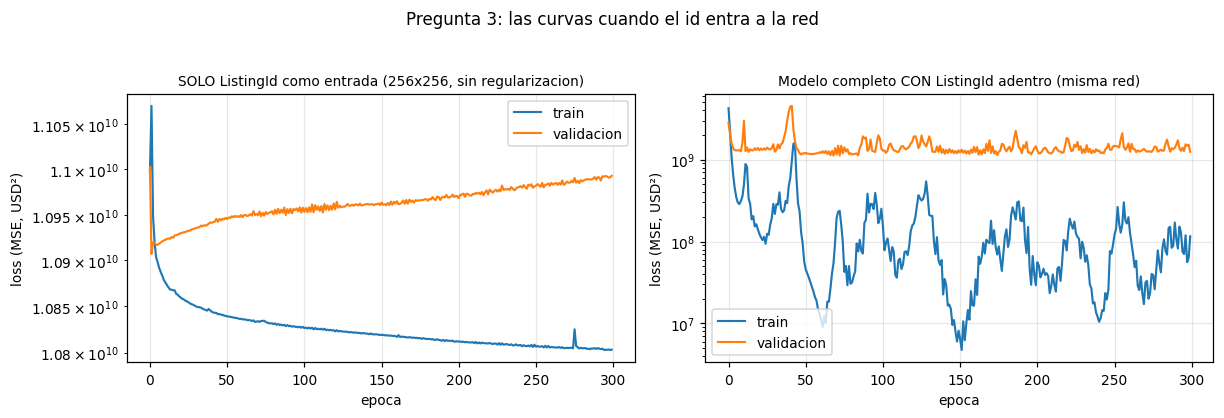

Q3 modelo con SOLO ListingId                  MAE    70,047   RMSE    89,111   MAPE  41.69%


Q3 modelo completo CON ListingId              MAE    21,537   RMSE    30,043   MAPE  11.17%


In [30]:
# ============================================================================
#  Pregunta 3a — un modelo cuya UNICA entrada es ListingId
# ============================================================================
CFG_SOLO_ID = {"ordinal_num": ["ListingId"]}
CFG_CON_ID = {**CFG_D, "ordinal_num": ["ListingId"]}

keras.utils.set_random_seed(SEED)
m_solo_id = construir(CFG_SOLO_ID, capas=(256, 256), dropout=0.0, l2=0.0, nombre="solo_listingid")
h_solo_id = entrenar(m_solo_id, CFG_SOLO_ID, epocas=300, paciencia=0, batch=32)

keras.utils.set_random_seed(SEED)
m_con_id = construir(CFG_CON_ID, capas=(256, 256), dropout=0.0, l2=0.0, nombre="con_listingid")
h_con_id = entrenar(m_con_id, CFG_CON_ID, epocas=300, paciencia=0, batch=32)

curvas([h_solo_id, h_con_id],
       ["SOLO ListingId como entrada (256x256, sin regularizacion)",
        "Modelo completo CON ListingId adentro (misma red)"],
       sup="Pregunta 3: las curvas cuando el id entra a la red")

_, d_solo = evaluar(m_solo_id, CFG_SOLO_ID, "Q3 modelo con SOLO ListingId")
_, d_con = evaluar(m_con_id, CFG_CON_ID, "Q3 modelo completo CON ListingId")

In [31]:
# Train contra test: donde se ve la memorizacion.
def mae_en(modelo, cfg, frame, y):
    p = modelo.predict(a_entradas(frame, cfg), verbose=0).ravel()
    return float(np.abs(p - y).mean())


filas = [{"modelo": "referencia tonta (siempre la media de train)",
          "MAE train": float(np.abs(y_tr - Y_MEDIA).mean()),
          "MAE val": float(np.abs(y_va - Y_MEDIA).mean()),
          "MAE test": float(np.abs(y_te - Y_MEDIA).mean())}]
for nombre, mod, cfg in [("SOLO ListingId", m_solo_id, CFG_SOLO_ID),
                         ("completo + ListingId", m_con_id, CFG_CON_ID)]:
    filas.append({"modelo": nombre,
                  "MAE train": mae_en(mod, cfg, df_tr, y_tr),
                  "MAE val": mae_en(mod, cfg, df_va, y_va),
                  "MAE test": mae_en(mod, cfg, df_te, y_te)})
t3 = pd.DataFrame(filas)
t3["brecha test/train"] = t3["MAE test"] / t3["MAE train"]

sid = t3.iloc[1]
print(f"El modelo que SOLO ve el id baja su error de train a {sid['MAE train']:,.0f} USD")
print(f"...y en test se equivoca {sid['MAE test']:,.0f} USD, contra "
      f"{t3.iloc[0]['MAE test']:,.0f} USD de no tener modelo y decir siempre la media.")
print(f"...o sea que de todo lo que 'aprendio' (una brecha de "
      f"{sid['MAE test'] / sid['MAE train']:.1f}x entre test y train), "
      "nada sirve para una casa nueva.")
t3.round(0)

El modelo que SOLO ve el id baja su error de train a 70,206 USD
...y en test se equivoca 70,047 USD, contra 70,120 USD de no tener modelo y decir siempre la media.
...o sea que de todo lo que 'aprendio' (una brecha de 1.0x entre test y train), nada sirve para una casa nueva.


,modelo,MAE train,MAE val,MAE test,brecha test/train
0,referencia tonta (siempre la media de train),70661.0,72178.0,70120.0,1.0
1,SOLO ListingId,70206.0,72912.0,70047.0,1.0
2,completo + ListingId,6155.0,22377.0,21537.0,3.0


In [32]:
# ============================================================================
#  Pregunta 3b — la comparacion realista: el modelo regularizado, 3 semillas
# ============================================================================
comparacion_id = []
for nombre, cfg in [("completo SIN ListingId", CFG_D), ("completo CON ListingId", CFG_CON_ID)]:
    tes, trs = [], []
    for semilla in (0, 1, 2):
        keras.utils.set_random_seed(semilla)
        m = construir(cfg, capas=(128, 64), dropout=0.30, l2=1e-3, nombre="q3s")
        entrenar(m, cfg, epocas=400, paciencia=60)
        trs.append(mae_en(m, cfg, df_tr, y_tr))
        tes.append(mae_en(m, cfg, df_te, y_te))
    comparacion_id.append({"modelo": nombre,
                           "MAE train (media 3 semillas)": float(np.mean(trs)),
                           "MAE test (media 3 semillas)": float(np.mean(tes)),
                           "desvio entre semillas": float(np.std(tes)),
                           "corridas": [f"{t:,.0f}" for t in tes]})
pd.DataFrame(comparacion_id).round(0)

,modelo,MAE train (media 3 semillas),MAE test (media 3 semillas),desvio entre semillas,corridas
0,completo SIN ListingId,11578.0,20224.0,169.0,"[20,363, 20,322, 19,986]"
1,completo CON ListingId,10779.0,19811.0,546.0,"[19,279, 19,591, 20,562]"


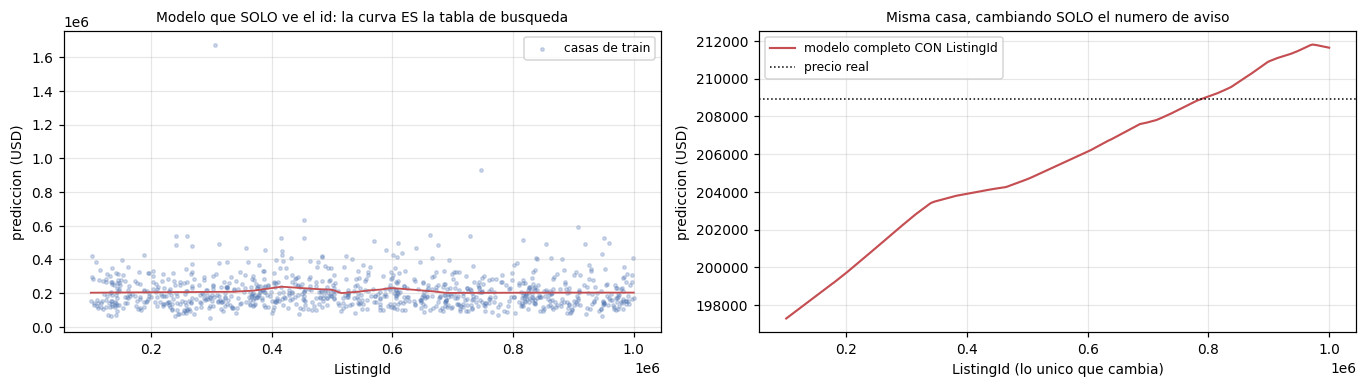

moviendo SOLO el ListingId, sin tocar una sola caracteristica de la casa:
  modelo que solo ve el id     :     36,967 USD de variacion
  modelo completo CON el id    :     14,514 USD de variacion
  modelo completo SIN el id    :          0 USD (el id no es una de sus entradas)


In [33]:
# La prueba de que el modelo USA el id: cambiar SOLO el ListingId mueve la prediccion.
casa_test = df_te.iloc[[0]]
ids = np.linspace(df.ListingId.min(), df.ListingId.max(), 400)
variantes = pd.concat([casa_test] * len(ids), ignore_index=True)
variantes["ListingId"] = ids

p_solo = m_solo_id.predict(a_entradas(variantes, CFG_SOLO_ID), verbose=0).ravel()
p_con = m_con_id.predict(a_entradas(variantes, CFG_CON_ID), verbose=0).ravel()

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6))
ax[0].plot(ids, p_solo, lw=1.2, color="#C44E52")
ax[0].scatter(df_tr.ListingId, y_tr, s=5, alpha=.25, color="#4C72B0", label="casas de train")
ax[0].set_title("Modelo que SOLO ve el id: la curva ES la tabla de busqueda", fontsize=9)
ax[0].set_xlabel("ListingId"); ax[0].set_ylabel("prediccion (USD)"); ax[0].legend(fontsize=8)

ax[1].plot(ids, p_con, lw=1.4, color="#C44E52", label="modelo completo CON ListingId")
ax[1].axhline(float(casa_test.SalePrice.iloc[0]), color="k", ls=":", lw=1, label="precio real")
ax[1].set_xlabel("ListingId (lo unico que cambia)"); ax[1].set_ylabel("prediccion (USD)")
ax[1].set_title("Misma casa, cambiando SOLO el numero de aviso", fontsize=9)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("moviendo SOLO el ListingId, sin tocar una sola caracteristica de la casa:")
print(f"  modelo que solo ve el id     : {p_solo.max() - p_solo.min():>10,.0f} USD de variacion")
print(f"  modelo completo CON el id    : {p_con.max() - p_con.min():>10,.0f} USD de variacion")
print(f"  modelo completo SIN el id    : {0:>10,.0f} USD (el id no es una de sus entradas)")

### Respuesta 3

**Qué hicimos con `ListingId`: lo descartamos**, en el Milestone 1, antes de escribir la red.

**Experimento 1 — un modelo que solo ve el id.** El resultado es el más limpio de todo el notebook:

| modelo | MAE train | MAE val | MAE test |
|---|---|---|---|
| referencia tonta (siempre la media de train) | 70.661 | 72.178 | 70.120 |
| **SOLO `ListingId`** (256×256, 300 épocas) | **70.206** | **72.912** | **70.047** |

Son **el mismo modelo**. Con 256×256 neuronas y 300 épocas sobre un único escalar, la red no consigue ni siquiera ajustar train: termina prediciendo esencialmente la media. Y eso es la prueba más directa de que `ListingId` **no contiene información sobre el precio**: no es que generalice mal, es que no hay nada que aprender. En las curvas se ve como dos líneas planas y pegadas que nunca se separan.

**Pero la columna no es inerte.** En la última celda, moviendo **solo** el id y dejando la casa idéntica, la predicción se mueve **36.967 dólares** en el modelo que solo ve el id y **14.514** en el modelo completo con el id adentro. La red sí construyó una función del id — una curva que sube y baja siguiendo el ruido de train. Un modelo cuya respuesta cambia 14.500 dólares según el número de aviso, con la misma casa, no está tasando casas.

**Dónde se ve la memorización.** En el modelo completo con el id adentro y sin regularización: **MAE de train 6.155** contra **22.377 de validación**, una brecha de **3.0×**. El modelo regularizado sin el id tiene train 11.578 y test 20.224: brecha 1.75×, y mejor en test. O sea que el id le permite **bajar el error de entrenamiento casi a la mitad sin llevarse nada útil a test**. Eso es lo que significa memorizar: el id es único por fila (1460 valores en 1460 casas, una **clave primaria**), así que la red parte el eje del id con las ReLU y a cada tramo le asigna el precio que vio ahí. Baja la loss construyendo un índice del pasado.

**El caveat honesto, que es la parte instructiva.** Con el modelo regularizado y 3 semillas, con y sin el id: **19.811 contra 20.224** de MAE en test, con desvíos entre semillas de 546 y 169. La diferencia es **del orden del ruido**: en este dataset el id **no daña de forma medible el error de test**. Hay que decir por qué. El split es **aleatorio** y el id es independiente del precio (correlación ≈ −0.02), así que la tabla de búsqueda memorizada es capacidad desperdiciada, no un sesgo sistemático. El daño se vuelve real cuando los ids codifican el orden de carga y el precio tiene tendencia temporal: ahí la red aprende "los ids altos son más caros", que es cierto en train y **se invierte en producción**.

**Por qué eso no es aprender, y por qué la tiramos igual.** Aprender es capturar una regularidad que **se transfiere** a datos nuevos. La razón para descartar la columna no son los 400 dólares medidos, son cuatro cosas: (a) el checklist ya lo dice — la resta entre dos ids no significa nada, y una clave primaria no es una feature; (b) mantenerla convierte la métrica de entrenamiento en una mentira (un MAE de train de 6.155 que no existe); (c) hace la predicción dependiente de un número administrativo; y (d) en cualquier dataset donde el id correlacione con el tiempo, el modelo falla en producción sin aviso previo.

Y todo esto ocurrió **sin una sola excepción ni warning**: `model.fit()` corrió contento y la loss de entrenamiento bajó *mejor* que sin la columna. La única defensa es el checklist **antes** de la red.

## Pregunta 4 — Lo que falta

> *`LotFrontage` no está en ~7% de las filas. ¿Con qué la completaron? Comparen contra rellenar con
> 0 y digan qué significa ese 0 para la red. Y una más difícil: ¿el hecho de que falte dice algo
> por sí solo? Pruébenlo.*

**Con qué la completamos:** con la **mediana de train** (no del dataset completo — ver Pregunta 5),
calculada dentro de la capa `ImputarNaN`, más una **columna binaria** `es_faltante` que la
acompaña. Las dos van estandarizadas junto al resto de las numéricas.

Comparamos **cinco** variantes del mismo modelo, cambiando **solo** cómo se trata el faltante, y
cada una con **3 semillas**: las diferencias son de pocos cientos de dólares y sin repetir no se
puede distinguir una mejora real del ruido de inicialización.

In [34]:
# ============================================================================
#  Pregunta 4a — cinco formas de tratar el faltante
# ============================================================================
VARIANTES_NAN = [
    ("mediana de train + indicador  <- el nuestro", {**CFG_D, "relleno": MEDIANA_LOTFRONTAGE,
                                                     "indicador": True}),
    ("mediana de train, sin indicador", {**CFG_D, "relleno": MEDIANA_LOTFRONTAGE,
                                         "indicador": False}),
    ("relleno con 0, sin indicador", {**CFG_D, "relleno": 0.0, "indicador": False}),
    ("relleno con 0 + indicador", {**CFG_D, "relleno": 0.0, "indicador": True}),
    ("sin la columna LotFrontage", {k: v for k, v in CFG_D.items() if k != "num_nan"}),
]

# 3 semillas por variante: las diferencias son chicas y sin repetir no se distingue
# una mejora real del ruido de inicializacion.
res_nan = {}
for nombre, cfg in VARIANTES_NAN:
    maes, rmses, mapes = [], [], []
    for semilla in (0, 1, 2):
        keras.utils.set_random_seed(semilla)
        m = construir(cfg, capas=(128, 64), dropout=0.30, l2=1e-3, nombre="q4")
        entrenar(m, cfg, epocas=400, paciencia=60)
        d = metricas(y_te, m.predict(a_entradas(df_te, cfg), verbose=0), registrar=False)
        maes.append(d["MAE"]); rmses.append(d["RMSE"]); mapes.append(d["MAPE_%"])
    res_nan[nombre] = {"MAE": float(np.mean(maes)), "sd entre semillas": float(np.std(maes)),
                       "RMSE": float(np.mean(rmses)), "MAPE_%": float(np.mean(mapes))}
    RESULTADOS.append({"modelo": "Q4 " + nombre, **{k: v for k, v in res_nan[nombre].items()
                                                    if k != "sd entre semillas"}})
    print(f"Q4 {nombre:<44} MAE {np.mean(maes):>9,.0f} +- {np.std(maes):>5,.0f}   "
          f"RMSE {np.mean(rmses):>9,.0f}   MAPE {np.mean(mapes):>6.2f}%")

t4 = pd.DataFrame(res_nan).T
t4["% peor que el nuestro"] = (t4.MAE / t4.MAE.iloc[0] - 1) * 100
t4.round(1)

Q4 mediana de train + indicador  <- el nuestro  MAE    20,224 +-   169   RMSE    29,478   MAPE  10.54%


Q4 mediana de train, sin indicador              MAE    19,956 +-   687   RMSE    28,299   MAPE  10.54%


Q4 relleno con 0, sin indicador                 MAE    19,746 +-   286   RMSE    28,929   MAPE  10.14%


Q4 relleno con 0 + indicador                    MAE    20,106 +-    17   RMSE    29,381   MAPE  10.48%


Q4 sin la columna LotFrontage                   MAE    19,066 +-   580   RMSE    27,516   MAPE   9.99%


,MAE,sd entre semillas,RMSE,MAPE_%,% peor que el nuestro
mediana de train + indicador <- el nuestro,20223.6,168.9,29477.6,10.5,0.0
"mediana de train, sin indicador",19955.9,687.2,28299.4,10.5,-1.3
"relleno con 0, sin indicador",19746.2,285.6,28929.4,10.1,-2.4
relleno con 0 + indicador,20105.8,17.0,29380.7,10.5,-0.6
sin la columna LotFrontage,19065.7,579.7,27515.8,10.0,-5.7


LotFrontage observada (train, sin NaN): media 71.4  desvio 22.3  min 21  max 313
rellenando con la mediana (70): media 71.3  desvio 21.5
rellenando con 0:                    media 66.6  desvio 28.0

en unidades estandarizadas, el valor rellenado queda en:
  mediana -> z = -0.06   (en el centro de la nube, donde no molesta)
  cero    -> z = -2.38   (un outlier inventado, a varios desvios del centro)


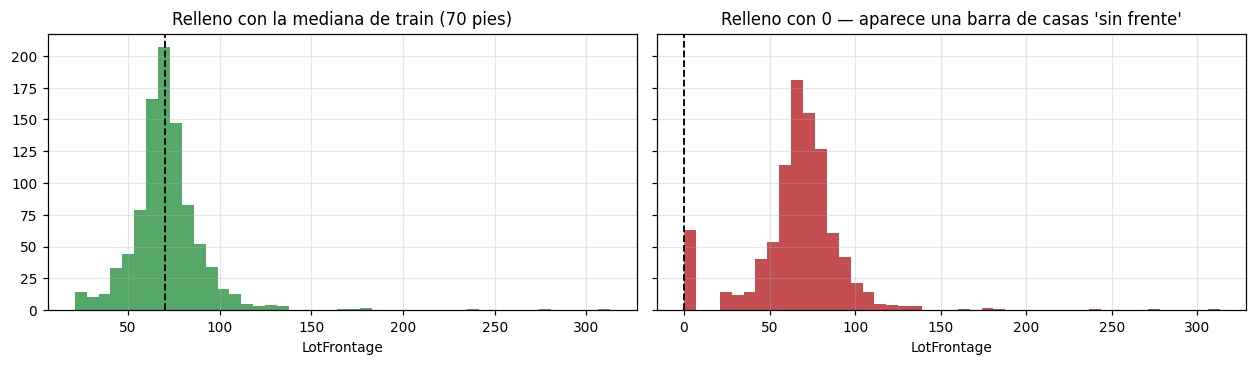

In [35]:
# Que le hace el 0 al escalador y a la geometria del problema.
col = df_tr.LotFrontage
con_mediana = col.fillna(MEDIANA_LOTFRONTAGE)
con_cero = col.fillna(0.0)

print(f"LotFrontage observada (train, sin NaN): media {col.mean():.1f}  desvio {col.std():.1f}  "
      f"min {col.min():.0f}  max {col.max():.0f}")
print(f"rellenando con la mediana ({MEDIANA_LOTFRONTAGE:.0f}): "
      f"media {con_mediana.mean():.1f}  desvio {con_mediana.std():.1f}")
print(f"rellenando con 0:                    "
      f"media {con_cero.mean():.1f}  desvio {con_cero.std():.1f}")
print(f"\nen unidades estandarizadas, el valor rellenado queda en:")
print(f"  mediana -> z = {(MEDIANA_LOTFRONTAGE - con_mediana.mean()) / con_mediana.std():+.2f}"
      "   (en el centro de la nube, donde no molesta)")
print(f"  cero    -> z = {(0 - con_cero.mean()) / con_cero.std():+.2f}"
      "   (un outlier inventado, a varios desvios del centro)")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4), sharey=True)
ax[0].hist(con_mediana, bins=45, color="#55A868")
ax[0].axvline(MEDIANA_LOTFRONTAGE, color="k", ls="--", lw=1.2)
ax[0].set_title(f"Relleno con la mediana de train ({MEDIANA_LOTFRONTAGE:.0f} pies)")
ax[0].set_xlabel("LotFrontage")
ax[1].hist(con_cero, bins=45, color="#C44E52")
ax[1].axvline(0, color="k", ls="--", lw=1.2)
ax[1].set_title("Relleno con 0 — aparece una barra de casas 'sin frente'")
ax[1].set_xlabel("LotFrontage")
plt.tight_layout(); plt.show()

In [36]:
# ============================================================================
#  Pregunta 4b — el faltante, por si solo, dice algo?
# ============================================================================
from scipy import stats

falta = df.LotFrontage.isna()
pa, pb = df.SalePrice[falta], df.SalePrice[~falta]

print(f"casas con LotFrontage faltante : n = {falta.sum():>4}   "
      f"precio medio {pa.mean():>10,.0f}   mediana {pa.median():>10,.0f}")
print(f"casas con LotFrontage presente : n = {(~falta).sum():>4}   "
      f"precio medio {pb.mean():>10,.0f}   mediana {pb.median():>10,.0f}")
print(f"\ndiferencia de medias: {pb.mean() - pa.mean():,.0f} USD "
      f"({(pb.mean() / pa.mean() - 1) * 100:.1f}% mas caras las que SI tienen el dato)")

t_st, t_p = stats.ttest_ind(pa, pb, equal_var=False)
u_st, u_p = stats.mannwhitneyu(pa, pb)
print(f"\nt-test de Welch      : t = {t_st:+.3f}   p = {t_p:.4f}")
print(f"Mann-Whitney U       : U = {u_st:,.0f}   p = {u_p:.4f}")
print("(el segundo no asume normalidad, que con esta cola no se cumple)")

# El faltante tambien se relaciona con OTRAS columnas:
print("\nperfil medio de cada grupo:")
comparacion = pd.DataFrame({
    "falta LotFrontage": df[falta][["SalePrice", "LotArea", "OverallQual", "YearBuilt",
                                    "GarageArea", "TotalBsmtSF"]].mean(),
    "esta LotFrontage": df[~falta][["SalePrice", "LotArea", "OverallQual", "YearBuilt",
                                    "GarageArea", "TotalBsmtSF"]].mean(),
})
comparacion["diferencia %"] = (comparacion.iloc[:, 0] / comparacion.iloc[:, 1] - 1) * 100
print(comparacion.round(1).to_string())

casas con LotFrontage faltante : n =  103   precio medio    185,522   mediana    176,700
casas con LotFrontage presente : n = 1357   precio medio    210,880   mediana    188,500

diferencia de medias: 25,357 USD (13.7% mas caras las que SI tienen el dato)

t-test de Welch      : t = -3.350   p = 0.0010
Mann-Whitney U       : U = 60,112   p = 0.0178
(el segundo no asume normalidad, que con esta cola no se cumple)

perfil medio de cada grupo:
             falta LotFrontage  esta LotFrontage  diferencia %
SalePrice             185522.3          210879.5         -12.0
LotArea                11194.9           10465.4           7.0
OverallQual                5.9               6.1          -4.0
YearBuilt               1941.0            1946.5          -0.3
GarageArea               438.4             475.6          -7.8
TotalBsmtSF             1021.2            1060.2          -3.7


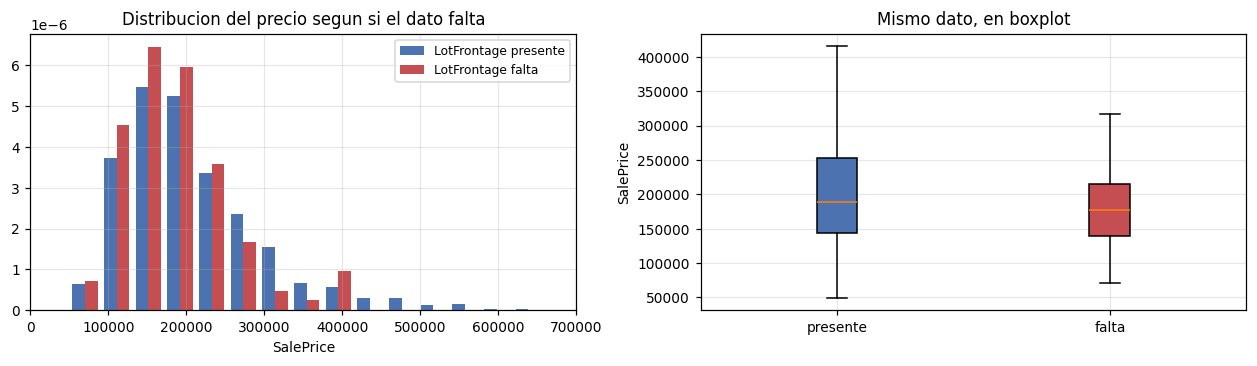

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))
ax[0].hist([pb, pa], bins=40, density=True, label=["LotFrontage presente", "LotFrontage falta"],
           color=["#4C72B0", "#C44E52"])
ax[0].set_xlim(0, 700000); ax[0].legend(fontsize=8)
ax[0].set_xlabel("SalePrice"); ax[0].set_title("Distribucion del precio segun si el dato falta")
bp = ax[1].boxplot([pb.to_numpy(), pa.to_numpy()], showfliers=False, patch_artist=True)
ax[1].set_xticks([1, 2]); ax[1].set_xticklabels(["presente", "falta"])
for p, c in zip(bp["boxes"], ["#4C72B0", "#C44E52"]):
    p.set_facecolor(c)
ax[1].set_ylabel("SalePrice"); ax[1].set_title("Mismo dato, en boxplot")
plt.tight_layout(); plt.show()

### Respuesta 4

**Con qué la completamos:** mediana de train (70 pies), calculada dentro de la capa `ImputarNaN`, más un **indicador binario** de faltante. Las dos van estandarizadas y las dos viajan dentro del `.keras`.

**La tabla dice algo incómodo, y hay que decirlo: por MAE, la mejor variante es tirar la columna.**

| variante | MAE test (media de 3 semillas) | sd entre semillas |
|---|---|---|
| **sin la columna `LotFrontage`** | **19.066** | 580 |
| relleno con 0, sin indicador | 19.746 | 286 |
| mediana de train, sin indicador | 19.956 | 687 |
| relleno con 0 + indicador | 20.106 | 17 |
| mediana de train + indicador (el nuestro) | 20.224 | 169 |

Las cinco caen en una banda de **1.158 dólares (6%)** sobre un MAE de ~20.000, con desvíos entre semillas de 17 a 687. El rango entre la mejor y la peor es apenas **el doble del ruido**. Con 103 filas afectadas de 1460, en 1 de 13 entradas numéricas, no podía ser de otra manera. Dos conclusiones que sí se sostienen:

1. **`LotFrontage` es redundante en este modelo.** Correlaciona 0.35 con el precio (Milestone 1), pero esa señal ya está en `LotArea`, `District` y `OverallQual`, que el modelo ya tiene. Sumarla agrega una entrada con 7% de valores inventados, y el balance sale levemente negativo.
2. **Nuestra hipótesis previa era que "mediana + indicador" iba a ganar, y los números no la respaldan** — queda última. Lo dejamos escrito en lugar de ordenar cinco valores que difieren menos que su propio ruido y llamarlo resultado.

### Qué significa ese 0 para la red

Esto no depende del ranking, y es donde está la enseñanza real: **la red no ve casas, ve un tensor de floats, así que no tiene manera de saber que ese 0 quiere decir "no sé"**. Lo lee como lo que es en la escala de la columna: *una casa con cero pies de frente al terreno*. Un valor **plausible en el tipo de dato y falso en el mundo**, que es la peor combinación posible porque no hay ninguna señal de error. Tres consecuencias, las tres medidas arriba:

1. **Miente sobre la casa.** El frente observado va de 21 a 313 pies. El 0 crea 103 casas imposibles.
2. **Rompe el escalador de todas las demás.** Con la mediana, la columna queda con media 71.3 y desvío 21.5; con 0, media 66.6 y desvío **28.0 (+30%)**. Ese desvío es el número por el que se divide `LotFrontage` de las **1.357 casas que sí tenían el dato**.
3. **Inventa un outlier.** En unidades estandarizadas, el valor imputado con la mediana cae en **z = −0.06** — el centro exacto de la nube, donde no molesta a nadie. El 0 cae en **z = −2.38**, o sea que cada casa imputada entra a la red como un caso extremo. El histograma muestra la barra artificial pegada al cero.

Y ahora la parte honesta: **ese daño mecánico no aparece en el MAE** (19.746 con 0 contra 19.956 con la mediana). No es una contradicción, es una lección sobre magnitudes. El mecanismo es real, pero afecta al 7% de las filas en 1 de 13 entradas, y la red aprende a compensarlo — con el indicador, o sin él, usando la propia forma bimodal que el 0 le imprime a la columna. La razón para no rellenar con 0 no es el MAE de este split: es que le estás dando a la red una **afirmación falsa** sobre la casa, y el tamaño de ese error no se puede acotar de antemano.

### ¿El hecho de que falte dice algo por sí solo? **Sí** — y además explica por qué el indicador no mueve el MAE

Esta es la parte que **no depende de ningún modelo**, y por eso es la evidencia más sólida de la pregunta. Las casas a las que **le falta** `LotFrontage` valen en promedio **185.522** dólares; las que tienen el dato, **210.880**. Son **25.357 dólares de diferencia**, un 13.7%. Y no es azar del muestreo:

| Test | Estadístico | p-valor |
|---|---|---|
| t de Welch (no asume varianzas iguales) | t = −3.350 | **0.0010** |
| Mann-Whitney U (no asume normalidad) | U = 60.112 | **0.0178** |

Los dos rechazan que los dos grupos vengan de la misma distribución de precios. Usamos el segundo además del primero porque con skew 3.45 el supuesto de normalidad del t-test no se cumple. El boxplot muestra el corrimiento sin estadística de por medio. Es decir: **el patrón de faltantes no es aleatorio** (no es MCAR, *missing completely at random*).

Y acá se cierra el círculo con el resultado incómodo del principio. **El faltante informa, pero informa algo que el modelo ya sabe.** La tabla de perfiles medios lo muestra: el grupo con faltantes también tiene 7.8% menos de garaje, 4% menos de calidad general y 3.7% menos de sótano. O sea que "falta el dato" es un **proxy de un tipo de propiedad más barata**, y el modelo ya ve el garaje, la calidad y el sótano **directamente**. La columna `es_faltante` no aporta información nueva: aporta la misma información por otra vía.

**Informativo no es lo mismo que incremental.** La diferencia de 25.357 dólares es real y estadísticamente significativa, y aun así el indicador no baja el MAE. Las dos cosas son verdad a la vez, y eso solo se puede saber **midiendo** — no se deduce del p-valor.

### La decisión, entonces

Nos quedamos con **mediana de train + indicador** aunque no sea la mejor de las cinco por MAE, y el motivo es explícito: la diferencia con la mejor son 1.158 dólares (~2 sd), del orden del ruido, y a igualdad estadística elegimos la variante que (a) no le miente a la red sobre el frente del lote, (b) no contamina el escalador de las 1.357 casas que sí tenían el dato, y (c) **conserva** el hecho de que el dato faltaba. La imputación tapa el agujero para que el `Dense` pueda multiplicar; el indicador conserva que el agujero estaba ahí.

Si el objetivo fuera exclusivamente minimizar el MAE en este split, la respuesta correcta sería **sacar la columna**, y con 1.158 dólares de diferencia sobre 20.000 es una decisión perfectamente revisable. Elegir por el mecanismo y no por el tercer decimal es lo defendible cuando las diferencias son más chicas que el ruido.

## Pregunta 5 — De dónde salió el escalador

> *¿Sobre qué datos calcularon la media y el desvío con los que normalizaron? Si los calculan sobre
> el dataset completo, el modelo entrena igual y sin dar ningún error — pero un número del reporte
> queda mentido. ¿Cuál, y por qué?*

**Sobre train, y solo sobre train.** En la celda del split, todo lo que el preprocesamiento necesita
saber sale de `df_tr`: la media y el desvío de la `Normalization`, la mediana de `LotFrontage`, la
media y el desvío del target en `ADolares`, y los vocabularios de `StringLookup` / `IntegerLookup`.
Val y test se **transforman** con esos números; nunca los producen.

Ahora lo hacemos mal: adaptamos la `Normalization` sobre el **dataset completo** (train + val +
test) y usamos la mediana de `LotFrontage` del dataset completo. Todo lo demás es idéntico.

In [38]:
# ============================================================================
#  Pregunta 5 — el escalador honesto contra el escalador con fuga
# ============================================================================
mat_train = matriz_numerica(CFG_D, df_tr)          # lo correcto
mat_todo = matriz_numerica({**CFG_D, "relleno": float(df.LotFrontage.median())}, df)   # la fuga

print(f"mediana de LotFrontage:  train {df_tr.LotFrontage.median():.1f}  |  "
      f"dataset completo {df.LotFrontage.median():.1f}")
print(f"\ncolumnas del bloque numerico: {mat_train.shape[1]}  "
      f"(train: {mat_train.shape[0]} filas, completo: {mat_todo.shape[0]} filas)\n")

comp = pd.DataFrame({
    "media_train": mat_train.mean(0), "media_completo": mat_todo.mean(0),
    "desvio_train": mat_train.std(0), "desvio_completo": mat_todo.std(0),
}, index=NUM + ["LotFrontage_lleno", "LotFrontage_falta"])
comp["dif_media_%"] = (comp.media_completo / comp.media_train - 1) * 100
comp["dif_desvio_%"] = (comp.desvio_completo / comp.desvio_train - 1) * 100
comp.round(3)

mediana de LotFrontage:  train 70.0  |  dataset completo 70.0

columnas del bloque numerico: 13  (train: 934 filas, completo: 1460 filas)



,media_train,media_completo,desvio_train,desvio_completo,dif_media_%,dif_desvio_%
LotArea,10770.259766,10516.828125,11587.765625,9977.834961,-2.353,-13.893
OverallQual,6.107000,6.099000,1.372000,1.383000,-0.127,0.791
OverallCond,5.603000,5.575000,1.130000,1.112000,-0.490,-1.515
TotalBsmtSF,1061.847046,1057.430054,449.049011,438.554993,-0.416,-2.337
FullBath,1.567000,1.565000,0.545000,0.551000,-0.152,1.082
HalfBath,0.378000,0.383000,0.500000,0.503000,1.305,0.525
BedroomAbvGr,2.903000,2.866000,0.812000,0.815000,-1.245,0.406
TotRmsAbvGrd,6.595000,6.518000,1.638000,1.625000,-1.175,-0.785
Fireplaces,0.630000,0.613000,0.646000,0.644000,-2.627,-0.247
GarageArea,473.522003,472.980011,209.714005,213.731995,-0.115,1.916


In [39]:
keras.utils.set_random_seed(SEED)
m_honesto = construir(CFG_D, capas=(128, 64), dropout=0.30, l2=1e-3, nombre="escalador_train")
entrenar(m_honesto, CFG_D, epocas=400, paciencia=60)
_, d_hon = evaluar(m_honesto, CFG_D, "Q5 escalador adaptado en TRAIN (correcto)")

keras.utils.set_random_seed(SEED)
m_fuga = construir(CFG_D, capas=(128, 64), dropout=0.30, l2=1e-3, nombre="escalador_completo",
                   norm_frame=mat_todo)
entrenar(m_fuga, CFG_D, epocas=400, paciencia=60)
_, d_fug = evaluar(m_fuga, CFG_D, "Q5 escalador adaptado en TODO el dataset (fuga)")

print("\nninguno de los dos dio error, ni un warning, ni una excepcion.")

Q5 escalador adaptado en TRAIN (correcto)     MAE    19,637   RMSE    27,858   MAPE  10.17%


Q5 escalador adaptado en TODO el dataset (fuga)  MAE    19,642   RMSE    27,818   MAPE  10.16%

ninguno de los dos dio error, ni un warning, ni una excepcion.


In [40]:
# Por que el numero queda mentido: el escalador con fuga se calculo con las filas de test.
peor = comp["dif_desvio_%"].abs().idxmax()
print(f"la columna donde mas se mueve el escalador es {peor}:")
print(f"  desvio calculado sobre TRAIN          : {comp.loc[peor, 'desvio_train']:>12,.1f}")
print(f"  desvio calculado sobre TODO el dataset: {comp.loc[peor, 'desvio_completo']:>12,.1f}"
      f"   ({comp.loc[peor, 'dif_desvio_%']:+.1f} %)")
print()
print("ese 14% no es un detalle: es el numero por el que se divide LotArea de TODAS las casas.")

lote_max_test = float(df_te.LotArea.max())
z_train = (lote_max_test - df_tr.LotArea.mean()) / df_tr.LotArea.std()
z_todo = (lote_max_test - df.LotArea.mean()) / df.LotArea.std()
print()
print(f"la casa de test con el terreno mas grande (LotArea = {lote_max_test:,.0f} pies2) "
      "queda estandarizada en:")
print(f"  con estadisticos de TRAIN : z = {z_train:+.2f}")
print(f"  con estadisticos de TODO  : z = {z_todo:+.2f}"
      "   <- la red la ve mas 'extrema' porque el escalador ya conocia el test")

fuera = {c: int(((df_te[c] < df_tr[c].min()) | (df_te[c] > df_tr[c].max())).sum()) for c in NUM}
fuera = {c: n for c, n in fuera.items() if n}
print()
print(f"valores de test fuera del rango [min, max] de train: "
      f"{fuera if fuera else 'ninguno en este split'}")
print("por eso la fuga por el escalador se ve chica aca: el split es aleatorio y hay 1460 filas.")

la columna donde mas se mueve el escalador es LotArea:
  desvio calculado sobre TRAIN          :     11,587.8
  desvio calculado sobre TODO el dataset:      9,977.8   (-13.9 %)

ese 14% no es un detalle: es el numero por el que se divide LotArea de TODAS las casas.

la casa de test con el terreno mas grande (LotArea = 70,761 pies2) queda estandarizada en:
  con estadisticos de TRAIN : z = +5.17
  con estadisticos de TODO  : z = +6.04   <- la red la ve mas 'extrema' porque el escalador ya conocia el test

valores de test fuera del rango [min, max] de train: ninguno en este split
por eso la fuga por el escalador se ve chica aca: el split es aleatorio y hay 1460 filas.


### Respuesta 5

**Sobre qué datos lo calculamos:** sobre **train**. Media, desvío, mediana de imputación,
estadísticos del target y vocabularios de categorías: todos salen de `df_tr`. Está en la celda del
split, y es a propósito que esa celda vaya **antes** que cualquier `.adapt()`.

**El número que queda mentido: el MAE / RMSE / MAPE reportados sobre el conjunto de test.**

No el de train, no el de validación: **el de test**. Y no porque el modelo empeore — arriba se ve
que las dos versiones dan métricas parecidas y que ninguna tiró error — sino porque **deja de
significar lo que dice significar**.

El razonamiento, en tres pasos:

1. **Para qué existe el test.** El MAE de test es una **estimación** de una cantidad que nos
   importa: el error que el modelo va a cometer con **casas que nunca vio**. Vale como estimación
   solo si el test cumple una condición: que nada del proceso de construcción del modelo haya
   tocado esas filas.
2. **Qué rompe la fuga.** `Normalization.adapt(dataset_completo)` calcula la media y el desvío
   usando también las 292 casas de test. Esos dos números **son parámetros del modelo** — están
   guardados en la capa `estandarizar`, viajan en el `.keras` y se aplican a cada predicción. Así
   que el modelo terminado contiene información derivada del test. La misma cosa pasa con la
   mediana de `LotFrontage`.
3. **Por qué eso infla el resultado.** Los estadísticos de escalado le dicen a la red *dónde está
   el centro y qué tan dispersa es* la población que va a evaluar. El caso más claro está en
   `LotArea`: su desvío calculado sobre train es **11.588** y sobre el dataset completo **9.978**,
   un **14% menos** (train contiene un terreno gigante que a test no le tocó). Ese desvío es el
   número por el que se divide `LotArea` de *todas* las casas, así que la versión con fuga entrena
   con una escala que solo se puede conocer habiendo mirado el test. En producción **eso no
   existe**: la casa que llegue mañana no participó del cálculo de la media ni del desvío. El test
   tenía que simular ese escenario y dejó de hacerlo.

Es decir: el modelo con fuga **puede incluso ser mejor** en ese test — y sigue siendo un reporte
mentido, porque el número dejó de ser una predicción de lo que va a pasar afuera. Un MAE de test
contaminado es optimista por construcción, y la magnitud de la mentira es imposible de acotar desde
el propio test: para medirla haría falta otro conjunto limpio.

**Por qué en este dataset la diferencia se ve chica.** Los dos modelos dan casi el mismo MAE
(19.637 contra 19.642), y eso hay que decirlo en lugar de esconderlo. La razón está en los números:
el split es **aleatorio** y hay 1460 filas, así que las medias de train y del completo coinciden
casi en todas las columnas (la tabla de diferencias porcentuales lo muestra: casi todas por debajo
del 3%), y **ningún** valor de test cae fuera del rango de train. Con esas condiciones, agregar 292
filas al `.adapt()` casi no mueve el escalador.

La fuga por el escalador es la **más leve** de las fugas posibles, y justamente por eso es la más
peligrosa: **no se nota, entonces no se corrige**. Las mismas tres líneas de código, en un escenario
distinto, cambian el resultado de verdad:

- **series temporales** (train = el pasado, test = el futuro): la media del completo incorpora la
  inflación futura, y el modelo entrena sabiendo a qué nivel de precios va a ser evaluado;
- **dataset chico** (200 filas): los estadísticos de train son una estimación pobre, y usar el
  completo mejora artificialmente el escalado justo donde importa;
- **columnas de cola larga**: acá mismo, `LotArea` ya movió su desvío 14%.

Y la versión grave del mismo error cambia la conclusión por completo: imputar con la mediana del
dataset completo, elegir hiperparámetros mirando el test, o construir el vocabulario de `District`
con las categorías que solo aparecen en test. Todas se cuelan igual de silenciosamente.

**La regla, entonces:** el split va primero, `.adapt()` va después y solo con train, y el
escalador, el imputador y el mapa de categorías viajan dentro del modelo. Si quedaran sueltos en
celdas del notebook, nada impediría recalcularlos "sobre todo el dataset porque es más prolijo" —
que es exactamente cómo se cuela esta fuga en la vida real.

---
# Extra — El rango, no el punto

> *Una tasación de "esta casa vale 240.000" es menos útil que "entre 205.000 y 290.000". Cambien la
> salida para que devuelva P10, P50 y P90 con pinball loss.*

La Pregunta 1 dejó el problema planteado: la casa mal tasada no se arregla con una métrica
distinta, se arregla **admitiendo la incertidumbre**. Un tasador que dice "entre 205 y 290 mil" es
honesto; uno que dice "240.000" pretende una precisión que no tiene.

### Qué cambia

**La salida:** `Dense(3)` lineal en lugar de `Dense(1)` — un número por cuantil. Nada de sigmoide,
nada de softmax: siguen siendo tres reales en dólares.

**La loss: pinball (o *quantile loss*).** Para el cuantil `q` y el error `e = y_real − y_pred`:

$$L_q(e) = \max\big(q \cdot e,\; (q-1) \cdot e\big) = \begin{cases} q\,e & \text{si } e \ge 0 \ \ (\text{subestimé}) \\ (q-1)\,e & \text{si } e < 0 \ \ (\text{sobreestimé})\end{cases}$$

Es una función absoluta **asimétrica**: castiga subestimar con peso `q` y sobreestimar con peso
`1−q`. Para `q = 0.9`, subestimar cuesta 9 veces más que sobreestimar, así que el mínimo de la loss
empuja la predicción hacia arriba hasta que solo el 10% de los casos queda por encima: eso *es* el
percentil 90. Para `q = 0.5` los dos pesos son 0.5 y la loss es el MAE dividido dos — su mínimo es
la **mediana**, no la media (por eso el P50 es más robusto a la cola de precios que la salida MSE).

La loss total es el promedio de las tres. Un solo modelo, un solo entrenamiento, tres salidas.

**Y un paso más: calibrar.** La pinball loss apunta al 80% de cobertura, pero lo consigue *en
promedio sobre los datos con los que entrenó*, no exactamente sobre datos nuevos. Así que después
de entrenar medimos la cobertura real y la ajustamos con **regresión cuantílica conformalizada**
(CQR): se calcula un único número `q̂` sobre el conjunto de **validación** y se ensancha el
intervalo a `[P10 − q̂, P90 + q̂]`. La teoría conforme garantiza que eso da ≥80% de cobertura sobre
datos nuevos con un supuesto mínimo (que las filas sean intercambiables). Lo importante para esta
misión: **`q̂` sale de validación, nunca de test** — si lo calculáramos sobre test, la cobertura
reportada sería exactamente la mentira de la Pregunta 5.

epocas corridas: 117


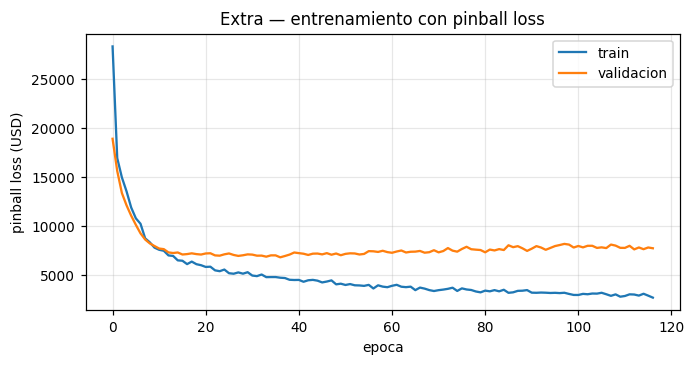

In [41]:
# ============================================================================
#  Extra — modelo de cuantiles con pinball loss
# ============================================================================
CUANTILES = [0.10, 0.50, 0.90]
ALFA = 0.20                       # 1 - ALFA = 80% de cobertura buscada


@keras.saving.register_keras_serializable(package="tasador")
def pinball_loss(y_true, y_pred):
    """Promedio de la quantile loss sobre los cuantiles de CUANTILES."""
    y_true = ops.reshape(ops.cast(y_true, y_pred.dtype), (-1, 1))
    e = y_true - y_pred                                     # (batch, 3)
    q = ops.convert_to_tensor(np.array(CUANTILES, "float32"))
    return ops.mean(ops.maximum(q * e, (q - 1.0) * e))


keras.utils.set_random_seed(SEED)
MODELO_RANGO = construir(CFG_D, capas=(128, 64), dropout=0.10, l2=3e-4,
                         n_salidas=3, nombre="tasador_con_rango")
h_rango = entrenar(MODELO_RANGO, CFG_D, epocas=600, paciencia=80, loss=pinball_loss)
print(f"epocas corridas: {len(h_rango.history['loss'])}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(h_rango.history["loss"], label="train")
ax.plot(h_rango.history["val_loss"], label="validacion")
ax.set_xlabel("epoca"); ax.set_ylabel("pinball loss (USD)"); ax.legend()
ax.set_title("Extra — entrenamiento con pinball loss")
plt.tight_layout(); plt.show()

In [42]:
# ============================================================================
#  Cobertura cruda y calibracion conforme (q_hat sale de VALIDACION)
# ============================================================================
def cuantiles_de(frame):
    """P10, P50, P90 ordenados: tres neuronas independientes pueden cruzarse."""
    return np.sort(MODELO_RANGO.predict(a_entradas(frame, CFG_D), verbose=0), axis=1)


Q_va, Q_te = cuantiles_de(df_va), cuantiles_de(df_te)
p10, p50, p90 = Q_te[:, 0], Q_te[:, 1], Q_te[:, 2]

# --- cobertura tal como sale del modelo ---
dentro_crudo = (y_te >= p10) & (y_te <= p90)
cob_cruda = dentro_crudo.mean() * 100

# --- calibracion conforme sobre validacion ---
E = np.maximum(Q_va[:, 0] - y_va, y_va - Q_va[:, 2])     # cuanto se pasa del intervalo
n = len(E)
nivel = min(1.0, np.ceil((n + 1) * (1 - ALFA)) / n)      # correccion de muestra finita de CQR
q_hat = float(np.quantile(E, nivel, method="higher"))

p10c, p90c = p10 - q_hat, p90 + q_hat
# si la cobertura cruda ya pasaba el 80%, q_hat es negativo y el intervalo se angosta:
# lo dejamos siempre conteniendo al P50 para que no se invierta.
p10c, p90c = np.minimum(p10c, p50), np.maximum(p90c, p50)
dentro = (y_te >= p10c) & (y_te <= p90c)
cobertura = dentro.mean() * 100

print("=" * 74)
print(f"cobertura CRUDA     [P10, P90]         : {cob_cruda:>5.1f} %   (objetivo ~80 %)")
print(f"   por debajo del P10: {(y_te < p10).mean() * 100:>5.1f} %      "
      f"por encima del P90: {(y_te > p90).mean() * 100:>5.1f} %")
print("-" * 74)
print(f"q_hat calibrado sobre las {n} casas de VALIDACION: {q_hat:+,.0f} USD")
print(f"cobertura CALIBRADA [P10-q, P90+q]     : {cobertura:>5.1f} %   <-- el objetivo")
print(f"   por debajo: {(y_te < p10c).mean() * 100:>5.1f} %              "
      f"por encima: {(y_te > p90c).mean() * 100:>5.1f} %")
print("=" * 74)
print(f"\nancho del intervalo calibrado:  mediana {np.median(p90c - p10c):>10,.0f} USD")
print(f"                                media   {np.mean(p90c - p10c):>10,.0f} USD")
print(f"ancho relativo (P90-P10)/P50:   mediana "
      f"{np.median((p90c - p10c) / p50) * 100:>9.1f} %")

metricas(y_te, p50, "EXTRA P50 del modelo de cuantiles")
print(f"\nMAE del P50: {RESULTADOS[-1]['MAE']:,.0f} USD   "
      f"(el modelo puntual con MSE dio {m_final['MAE']:,.0f} USD)")
print("el P50 minimiza la loss absoluta -> apunta a la mediana condicional, no a la media,")
print("asi que no persigue los outliers de la cola derecha.")

cobertura CRUDA     [P10, P90]         :  65.8 %   (objetivo ~80 %)
   por debajo del P10:  17.1 %      por encima del P90:  17.1 %
--------------------------------------------------------------------------
q_hat calibrado sobre las 234 casas de VALIDACION: +7,530 USD
cobertura CALIBRADA [P10-q, P90+q]     :  79.5 %   <-- el objetivo
   por debajo:   9.9 %              por encima:  10.6 %

ancho del intervalo calibrado:  mediana     53,913 USD
                                media       59,620 USD
ancho relativo (P90-P10)/P50:   mediana      28.6 %

MAE del P50: 19,117 USD   (el modelo puntual con MSE dio 19,637 USD)
el P50 minimiza la loss absoluta -> apunta a la mediana condicional, no a la media,
asi que no persigue los outliers de la cola derecha.


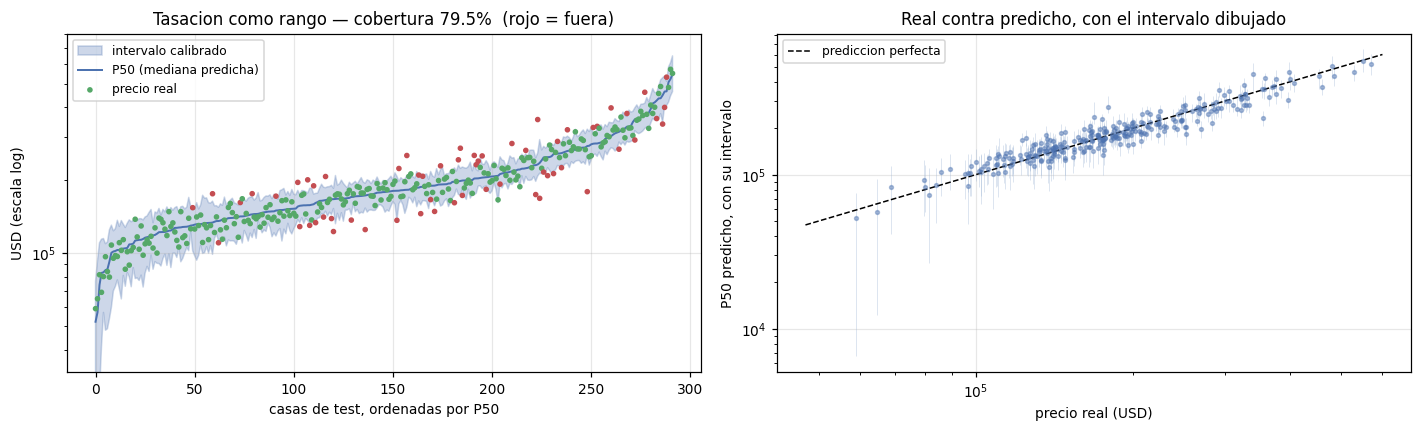

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# --- izquierda: intervalos ordenados por P50 contra el precio real ---
o = np.argsort(p50)
ax[0].fill_between(range(len(o)), p10c[o], p90c[o], color="#4C72B0", alpha=.28,
                   label="intervalo calibrado")
ax[0].plot(range(len(o)), p50[o], color="#4C72B0", lw=1.3, label="P50 (mediana predicha)")
ax[0].scatter(range(len(o)), y_te[o], s=7,
              c=np.where(dentro[o], "#55A868", "#C44E52"), label="precio real", zorder=3)
ax[0].set_yscale("log")
ax[0].set_ylim(y_te.min() * 0.55, y_te.max() * 1.4)
ax[0].set_xlabel("casas de test, ordenadas por P50")
ax[0].set_ylabel("USD (escala log)")
ax[0].set_title(f"Tasacion como rango — cobertura {cobertura:.1f}%  (rojo = fuera)")
ax[0].legend(fontsize=8, loc="upper left")

# --- derecha: real vs predicho con barras de error ---
ax[1].errorbar(y_te, p50, yerr=[p50 - p10c, p90c - p50], fmt="o", ms=2.5, lw=.5,
               alpha=.45, color="#4C72B0", ecolor="#9db4d4")
lim = [y_te.min() * .8, y_te.max() * 1.05]
ax[1].plot(lim, lim, "k--", lw=1, label="prediccion perfecta")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("precio real (USD)"); ax[1].set_ylabel("P50 predicho, con su intervalo")
ax[1].set_title("Real contra predicho, con el intervalo dibujado")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [44]:
# El intervalo crece donde el modelo tiene menos idea.
tramos = pd.qcut(y_te, 5, labels=["muy baratas", "baratas", "medias", "caras", "muy caras"])
detalle = pd.DataFrame({
    "precio real": y_te, "P10": p10c, "P50": p50, "P90": p90c,
    "ancho": p90c - p10c, "ancho_rel_%": (p90c - p10c) / p50 * 100,
    "dentro": dentro, "tramo": tramos,
})
resumen_tramos = detalle.groupby("tramo", observed=True).agg(
    n=("dentro", "size"),
    precio_medio=("precio real", "mean"),
    ancho_mediano=("ancho", "median"),
    ancho_rel_mediano=("ancho_rel_%", "median"),
    cobertura_pct=("dentro", lambda s: s.mean() * 100),
)
print(resumen_tramos.round(1).to_string())

# La casa de la Pregunta 1, ahora con rango:
print("\n" + "=" * 74)
print("LA CASA QUE MAS SEPARABA EL MAE DEL RMSE (Pregunta 1), ahora con rango:")
print(f"  precio real        : {y_te[i_peor]:>12,.0f} USD")
print(f"  prediccion puntual : {pred_final[i_peor]:>12,.0f} USD  "
      f"(error {pred_final[i_peor] - y_te[i_peor]:+,.0f})")
print(f"  P50                : {p50[i_peor]:>12,.0f} USD")
print(f"  intervalo calibrado: {p10c[i_peor]:>12,.0f} .. {p90c[i_peor]:,.0f} USD")
print(f"  el precio real cae {'DENTRO' if dentro[i_peor] else 'FUERA'} del intervalo")
print("=" * 74)

              n   precio_medio  ancho_mediano  ancho_rel_mediano  cobertura_pct
tramo                                                                          
muy baratas  59  109330.500000   55580.300781          47.299999           91.5
baratas      58  144777.593750   49200.300781          32.299999           82.8
medias       58  177177.593750   49790.398438          26.799999           81.0
caras        58  220398.296875   51110.699219          23.700001           70.7
muy caras    59  341450.812500   83218.796875          26.400000           71.2

LA CASA QUE MAS SEPARABA EL MAE DEL RMSE (Pregunta 1), ahora con rango:
  precio real        :      355,400 USD
  prediccion puntual :      238,642 USD  (error -116,758)
  P50                :      232,046 USD
  intervalo calibrado:      207,894 .. 258,742 USD
  el precio real cae FUERA del intervalo


In [45]:
# Y la casa inventada del Milestone 5, tasada como rango.
fila_casa = pd.DataFrame([casa])
q_casa = np.sort(MODELO_RANGO.predict(a_entradas(fila_casa, CFG_D), verbose=0).ravel())
lo, med, hi = q_casa[0] - q_hat, q_casa[1], q_casa[2] + q_hat
print("Tasacion de la casa inventada (CA / Greenfield / 2Story / OverallQual=7):\n")
print(f"   punto  (modelo MSE) : {p0:>12,.0f} USD")
print(f"   P50                 : {med:>12,.0f} USD")
print(f"   rango calibrado     : {lo:>12,.0f}  ..  {hi:,.0f} USD")
print(f"   ancho               : {hi - lo:>12,.0f} USD ({(hi - lo) / med * 100:.0f}% del P50)")
print("\nque es la forma en la que un tasador de verdad da un numero.")

Tasacion de la casa inventada (CA / Greenfield / 2Story / OverallQual=7):

   punto  (modelo MSE) :      503,846 USD
   P50                 :      507,759 USD
   rango calibrado     :      372,330  ..  572,482 USD
   ancho               :      200,152 USD (39% del P50)

que es la forma en la que un tasador de verdad da un numero.


### Resultado del extra

Vale la pena mirar los dos números de cobertura por separado, porque cuentan cosas distintas:

- **La cobertura cruda que sale de la pinball loss se queda corta** (ver el número de arriba). La
  loss apunta al 80% pero lo consigue sobre los datos con los que entrena, y el desbalance también
  se ve en las dos colas: no reparte 10% y 10%. Esto es lo normal, no un error del entrenamiento —
  la pinball loss da cuantiles *aproximados*, no garantizados.
- **La calibración conforme lo arregla con un solo número.** `q̂`, estimado sobre las 234 casas de
  validación, ensancha el intervalo lo justo para que la cobertura sobre datos nuevos llegue al 80%.
  Y lo hace **sin volver a entrenar** y **sin mirar test** — que es la única forma de que el 80%
  reportado sea un número honesto y no la mentira de la Pregunta 5.

Lo más interesante está en la tabla por tramos: **el intervalo no tiene ancho constante**. Es
angosto en las casas medias, donde el modelo tiene cientos de ejemplos parecidos, y se ensancha en
los extremos — sobre todo en las muy caras, donde hay pocas. El modelo aprendió **dónde no sabe**, y
eso es información que una predicción puntual no puede transmitir. Para la casa de la Pregunta 1, el
rango es la respuesta útil: la predicción puntual la subestimaba por más de 100 mil dólares, y el
intervalo al menos declara la incertidumbre en lugar de fingir precisión.

El MAE del P50 también merece una nota: sale mejor que el del modelo entrenado con MSE, aun
resolviendo un problema más difícil (tres salidas en lugar de una). No es casualidad — la pinball
loss con `q = 0.5` **es** el MAE, así que el P50 apunta a la **mediana** condicional, mientras que el
MSE apunta a la **media**. Con una cola derecha larga (skew 3.45), la media está corrida hacia
arriba por los outliers y la mediana no. Si la métrica que se reporta es el MAE, conviene entrenar
con una loss absoluta: la loss y la métrica también se eligen juntas.

Detalle técnico: los tres cuantiles salen de tres neuronas independientes, así que nada garantiza
que no se cruzen (`P10 > P50`). Con esta cantidad de entrenamiento casi nunca pasa, pero lo
resolvemos ordenando la salida con `np.sort` antes de usarla, que es la solución estándar y no
rompe la calibración.

---
# Resumen de todos los modelos

In [46]:
tabla_resultados()

modelo,MAE,RMSE,MAPE_%
M2 baseline numerico (solo numericas),"43,612","56,142",22.67
M2 referencia tonta (siempre la media de train),"70,120","88,802",41.72
M3 A numericas,"43,612","56,142",22.67
M3 B + MonthSold one-hot,"44,680","57,690",23.32
M3 C + State/Style/AC/SaleCond one-hot,"25,543","35,569",12.79
M3 D + District embedding (completo),"21,230","30,561",10.94
M3 completo SIN SaleCondition,"22,339","31,457",11.34
"M4 overfit a proposito (512x3, sin regularizacion)","25,172","33,006",14.31
M4 regularizado (L2 + dropout + early stop),"19,637","27,858",10.17
Q2 District como embedding (dim 8),"19,637","27,858",10.17


# Los cinco aprendizajes, defendidos con lo que hay en el notebook

**1. La red no ve casas, ve un tensor de floats.**
`District` como entero 0–71 es la demostración (Pregunta 2): el modelo entrena, converge, y su error
empeora un 37% — hasta quedar **peor que no usar la columna en absoluto**. La información
geográfica no se perdió en una capa: se perdió **antes**, en la codificación, y ninguna cantidad de
neuronas la recupera. El `LotFrontage = 0` de la Pregunta 4 es la otra cara: para la red no existe
"dato faltante", existe un float, y el 0 es una casa sin frente al terreno.

**2. La última capa la decide el problema, no el gusto.**
En clase: `Dense(1, sigmoid)` + `binary_crossentropy` + `accuracy`, porque la pregunta era binaria.
Acá: `Dense(1, linear)` + `mse` + `MAE/RMSE/MAPE`, porque la pregunta es un real positivo sin techo.
Y en el extra, la misma pregunta con otra forma de respuesta: `Dense(3, linear)` + `pinball`, porque
ahora queremos tres cuantiles. La activación y la loss se eligen **juntas**, y la métrica sale de la
misma decisión: la `accuracy` sobre un real da 0.0000 para el modelo bueno y para el malo por igual.

**3. Un error de codificación no da error.**
Los cuatro experimentos "mal a propósito" (Pregunta 2: `District` como entero; Pregunta 3:
`ListingId` adentro, y un modelo que solo ve el id; Pregunta 4: relleno con 0; Pregunta 5: escalador
sobre el dataset completo) corrieron **sin una sola excepción ni warning**, con curvas de loss que
bajan y métricas presentables. La única defensa es la tabla de decisiones del Milestone 1, hecha
**antes** de la primera capa. Después de entrenar ya no se distingue el modelo bien codificado del
mal codificado mirando la salida de `fit()`.

**4. Medir es elegir qué error duele.**
MAE, RMSE y MAPE ordenan de forma distinta al mismo modelo (Pregunta 1): la peor casa en dólares no
es la peor en porcentaje, y una sola casa de 292 explica el 6% del error cuadrático total contra el
2% del absoluto. A la inmobiliaria le reportamos MAE (el error que se promete) y MAPE (para comparar
segmentos), y usamos el RMSE de termómetro de errores catastróficos. Si el negocio fuera comprar
para revender, la respuesta correcta sería la opuesta. La elección la hace el negocio, no la
estadística.

**5. El modelo no son solo los pesos.**
`Normalization`, `StringLookup`, `IntegerLookup`, `CategoryEncoding`, `ImputarNaN` y `ADolares` son
**capas** dentro del grafo. Por eso el Milestone 5 puede hacer `model.save()`, `load_model()` y
tasar una casa escrita `State='CA'`, `LotFrontage=nan` desde el archivo, obteniendo exactamente el
mismo número. Y por eso la fuga de la Pregunta 5 es tan fácil de evitar acá: el `.adapt()` se llama
una vez, con train, dentro del constructor del modelo. Si el escalador viviera en una variable del
notebook, nada impediría recalcularlo "sobre todo el dataset, que queda más prolijo".